# Scenario-Conditional Loan Forecasting Under NGFS Climate Paths

**Phase 2 — VAR Estimation, Conditional Forecasts, and Scenario Analysis**

This notebook implements the full modeling pipeline:
1. Load FRED historical data + NGFS NiGEM macro-financial scenarios
2. Prepare annual-frequency data with COVID dummy treatment
3. Extract scenario paths for all 3 IAM model families (GCAM, REMIND, MESSAGEix)
4. Estimate AR baselines as benchmarks
5. Estimate VAR models linking loan growth to macro variables
6. Evaluate out-of-sample forecast accuracy (excluding COVID)
7. Generate scenario-conditional loan forecasts (2026-2050) under 3 key NGFS paths x 3 IAM models
8. Reconstruct cumulative loan balance impacts
9. Produce actionable insights for executive decision-making

**Modeling decisions** are informed by BofA Q&A (Feb 20, 2026) -- see `CLAUDE.md` for full notes.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 150
SAVE_DPI = 300
FIG_DIR = 'outputs/figures/'
DATA_DIR = 'data/raw/'

# NGFS color scheme (consistent with exploration notebook)
SCENARIO_COLORS = {
    'Net Zero 2050': '#1b9e77',
    'Below 2\u00b0C': '#66a61e',
    'Delayed transition': '#d95f02',
    'Nationally Determined Contributions (NDCs)': '#e7298a',
    'Fragmented World': '#a6761d',
    'Current Policies': '#e6ab02',
    'Baseline': '#666666',
}

# 3 key scenarios for forecasting (orderly, disorderly, hot house)
KEY_SCENARIOS = ['Net Zero 2050', 'Delayed transition',
                 'Nationally Determined Contributions (NDCs)']
KEY_SCENARIO_SHORT = {'Net Zero 2050': 'Net Zero',
                      'Delayed transition': 'Delayed Trans.',
                      'Nationally Determined Contributions (NDCs)': 'NDCs'}

print('Setup complete.')

Setup complete.


### Load FRED Series

In [2]:
# Load all 7 FRED series
series_info = {
    'BUSLOANS':  ('C&I Loans (Billions $)', 'M'),
    'CONSUMER':  ('Consumer Loans (Billions $)', 'M'),
    'GDPC1':     ('Real GDP (Billions 2017$)', 'Q'),
    'UNRATE':    ('Unemployment Rate (%)', 'M'),
    'FEDFUNDS':  ('Fed Funds Rate (%)', 'M'),
    'DGS10':     ('10-Year Treasury Yield (%)', 'M'),
    'CPIAUCSL':  ('CPI (Index)', 'M'),
}

fred = {}
for ticker, (label, freq) in series_info.items():
    df = pd.read_csv(f'{DATA_DIR}{ticker}.csv', parse_dates=['date'], index_col='date')
    df.columns = [ticker]
    df = df.replace('.', np.nan).dropna()
    df[ticker] = df[ticker].astype(float)
    fred[ticker] = df
    print(f'{ticker:12s} | {label:35s} | {df.index[0].date()} to {df.index[-1].date()} | n={len(df):>5d} | {freq}')

BUSLOANS     | C&I Loans (Billions $)              | 1947-01-01 to 2025-12-01 | n=  948 | M
CONSUMER     | Consumer Loans (Billions $)         | 1947-01-01 to 2025-12-01 | n=  948 | M
GDPC1        | Real GDP (Billions 2017$)           | 1947-01-01 to 2025-07-01 | n=  315 | Q
UNRATE       | Unemployment Rate (%)               | 1948-01-01 to 2026-01-01 | n=  936 | M
FEDFUNDS     | Fed Funds Rate (%)                  | 1954-07-01 to 2026-01-01 | n=  859 | M
DGS10        | 10-Year Treasury Yield (%)          | 1962-01-02 to 2026-02-11 | n=16012 | M
CPIAUCSL     | CPI (Index)                         | 1947-01-01 to 2026-01-01 | n=  948 | M


### Load NGFS NiGEM Data

In [3]:
nigem_raw = pd.read_excel(f'{DATA_DIR}ngfs-phase5-nigem.xlsx', sheet_name='data')
nigem_us = nigem_raw[nigem_raw['Region'] == 'NiGEM NGFS v1.24.2|United States'].copy()
nigem_us = nigem_us.drop_duplicates(subset=['Model', 'Scenario', 'Variable'])

year_cols = [c for c in nigem_us.columns if isinstance(c, str) and c.isdigit()]
years = [int(y) for y in year_cols]

MODELS = sorted(nigem_us['Model'].unique())
MODEL_SHORT = {m: m.split('[')[1].rstrip(']') if '[' in m else m for m in MODELS}

print(f'NiGEM U.S. rows: {len(nigem_us)}')
print(f'Year range: {year_cols[0]}-{year_cols[-1]}')
print(f'IAM Models ({len(MODELS)}):')
for m in MODELS:
    print(f'  {MODEL_SHORT[m]}')
print(f'Scenarios: {sorted(nigem_us["Scenario"].unique())}')

NiGEM U.S. rows: 1824
Year range: 2022-2050
IAM Models (3):
  GCAM 6.0 NGFS
  MESSAGEix-GLOBIOM 2.0-M-R12-NGFS
  REMIND-MAgPIE 3.3-4.8
Scenarios: ['Baseline', 'Below 2°C', 'Current Policies', 'Delayed transition', 'Fragmented World', 'Nationally Determined Contributions (NDCs)', 'Net Zero 2050']


## 2. Data Preparation

**Transformations** (course convention + BofA guidance):
- **Loan growth**: $g_t = 100 \times \ln(Y_t / Y_{t-1})$ -- stationary, interpretable
- **GDP growth**: same log-growth transformation
- **CPI inflation**: same log-growth transformation
- **Unemployment & rates**: first differences (already in % units)
- **COVID dummy**: 1 for 2020-03 through 2021-06 (BofA confirmed)
- **Frequency**: aggregate monthly to **annual averages** (matches NGFS)

*BofA: "Use dummy variables for COVID -- that's how a lot of people have been doing it."*

In [4]:
# --- Monthly transformations ---
monthly = pd.DataFrame(index=fred['BUSLOANS'].index)

# Log growth rates for level series (x 100 for percentage)
for ticker in ['BUSLOANS', 'CONSUMER', 'CPIAUCSL']:
    monthly[f'{ticker}_g'] = 100 * np.log(fred[ticker][ticker] / fred[ticker][ticker].shift(1))

# GDPC1 is quarterly -- resample to monthly by forward-fill, then compute growth
gdp_m = fred['GDPC1'].resample('MS').ffill()
monthly['GDPC1_g'] = 100 * np.log(gdp_m['GDPC1'] / gdp_m['GDPC1'].shift(1))

# First differences for rate/percentage variables
for ticker in ['UNRATE', 'FEDFUNDS', 'DGS10']:
    monthly[f'{ticker}_chg'] = fred[ticker][ticker].diff()

# COVID dummy (BofA: Mar 2020 - Jun 2021)
monthly['COVID'] = ((monthly.index >= '2020-03-01') & (monthly.index <= '2021-06-01')).astype(int)

monthly = monthly.dropna()
print(f'Monthly panel: {monthly.index[0].date()} to {monthly.index[-1].date()}, {len(monthly)} obs')
print(f'COVID dummy: {monthly["COVID"].sum():.0f} months flagged')
print(monthly.describe().round(3))

Monthly panel: 1962-02-01 to 2025-07-01, 488 obs
COVID dummy: 11 months flagged
       BUSLOANS_g  CONSUMER_g  CPIAUCSL_g  GDPC1_g  UNRATE_chg  FEDFUNDS_chg  \
count     488.000     488.000     488.000  488.000     488.000       488.000   
mean        0.556       0.600       0.307    0.190      -0.003         0.024   
std         1.068       1.410       0.306    0.707       0.518         0.494   
min        -3.708      -3.510      -0.864   -8.204      -2.200        -6.630   
25%         0.078       0.157       0.138    0.000      -0.100        -0.050   
50%         0.574       0.522       0.265    0.000       0.000         0.010   
75%         1.037       0.958       0.453    0.000       0.100         0.130   
max        13.020      26.676       1.794    7.476      10.400         3.050   

       DGS10_chg    COVID  
count    488.000  488.000  
mean      -0.001    0.023  
std        0.070    0.149  
min       -0.300    0.000  
25%       -0.040    0.000  
50%        0.000    0.000  
75%

### Aggregate to Annual Frequency

In [5]:
# Aggregate monthly to annual: means for growth rates and changes, max for COVID dummy
# Restrict to 1990+ for training window (BofA: "at least 3 decades")
annual = monthly.loc['1990-01-01':].resample('YE').agg({
    'BUSLOANS_g': 'mean',     # average monthly growth
    'CONSUMER_g': 'mean',
    'CPIAUCSL_g': 'mean',
    'GDPC1_g': 'mean',
    'UNRATE_chg': 'sum',       # cumulative annual change in unemployment
    'FEDFUNDS_chg': 'sum',     # cumulative annual change in fed funds
    'DGS10_chg': 'sum',        # cumulative annual change in 10y yield
    'COVID': 'max',            # 1 if any month in that year is COVID
})

# Convert monthly mean growth to approximate annual growth (x 12)
for col in ['BUSLOANS_g', 'CONSUMER_g', 'CPIAUCSL_g', 'GDPC1_g']:
    annual[col] = annual[col] * 12

# Use year as index for clarity
annual.index = annual.index.year
annual.index.name = 'Year'

# Drop incomplete final year if needed
if annual.index[-1] > 2025:
    annual = annual.loc[:2025]

print(f'Annual panel: {annual.index[0]}-{annual.index[-1]}, {len(annual)} observations')
print(f'COVID years: {list(annual[annual["COVID"] == 1].index)}')
print(f'\n--- Annual Summary ---')
print(annual.describe().round(3))

Annual panel: 1990-2025, 36 observations
COVID years: [2020, 2021]

--- Annual Summary ---
       BUSLOANS_g  CONSUMER_g  CPIAUCSL_g  GDPC1_g  UNRATE_chg  FEDFUNDS_chg  \
count      36.000      36.000      36.000   36.000      36.000        36.000   
mean        3.816       5.002       2.631    2.472       0.011        -0.041   
std         8.129       7.940       1.558    2.734       0.964         1.059   
min       -24.030      -9.143      -0.111   -3.679      -1.900        -2.660   
25%        -1.986       1.297       1.613    0.413      -0.400        -0.422   
50%         6.442       4.069       2.557    1.885      -0.200         0.005   
75%         9.472       7.556       3.080    4.331       0.225         0.443   
max        17.377      41.463       7.652    8.049       4.300         3.060   

       DGS10_chg   COVID  
count     36.000  36.000  
mean       0.002   0.056  
std        0.208   0.232  
min       -0.320   0.000  
25%       -0.132   0.000  
50%        0.005   0.000  

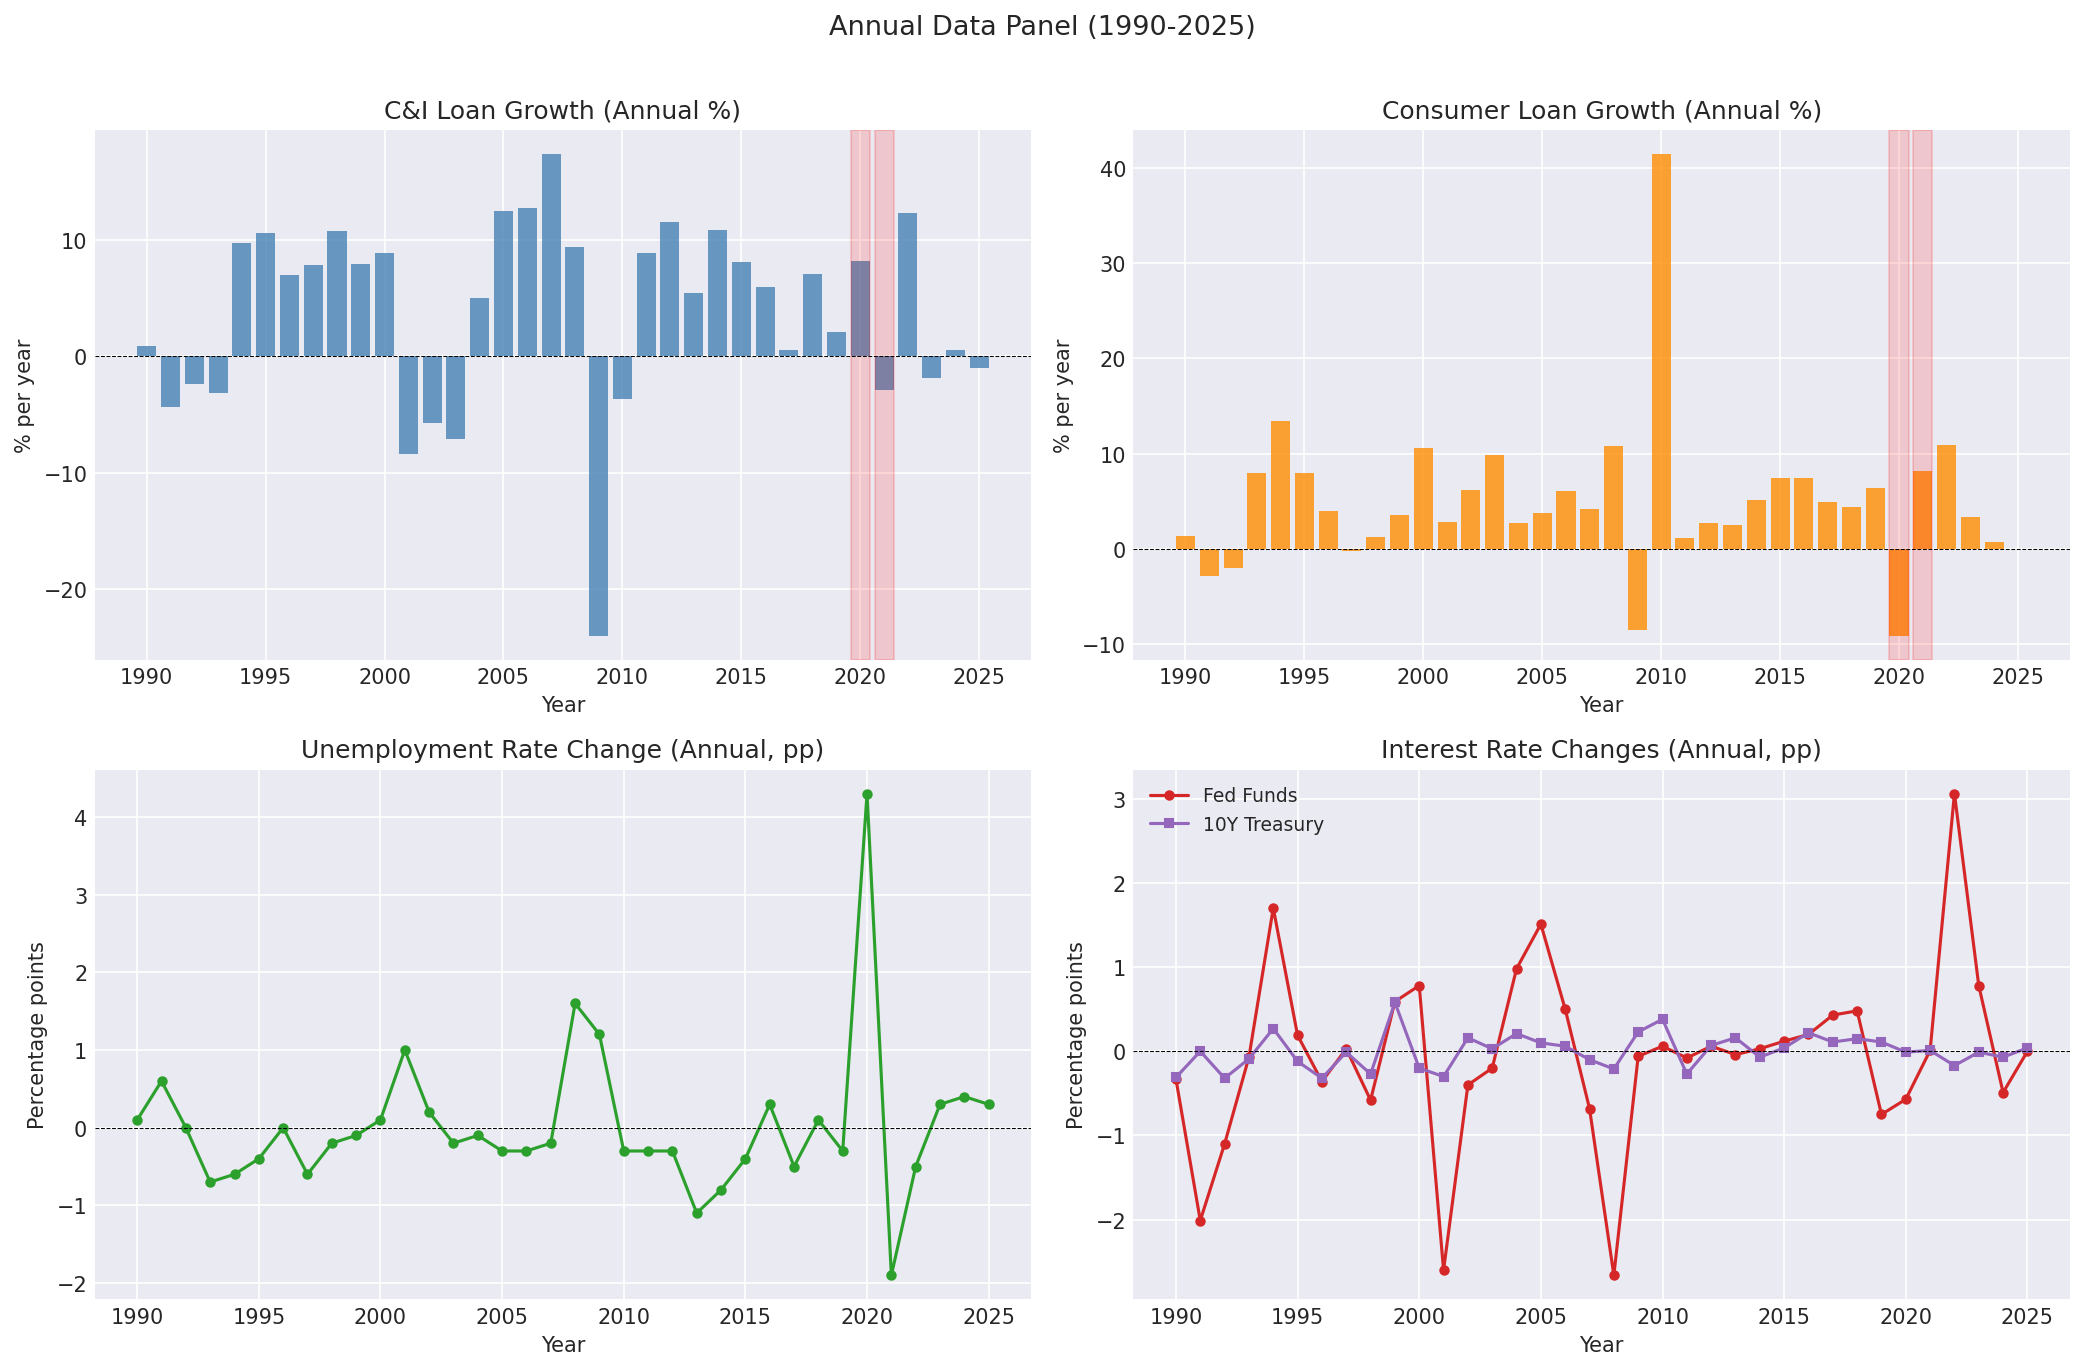

In [6]:
# Visualize annual series
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.bar(annual.index, annual['BUSLOANS_g'], color='steelblue', alpha=0.8, label='C&I Loans')
ax.axhline(0, color='black', lw=0.5, ls='--')
for yr in [2020, 2021]:
    ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.15, color='red')
ax.set_title('C&I Loan Growth (Annual %)')
ax.set_ylabel('% per year')

ax = axes[0, 1]
ax.bar(annual.index, annual['CONSUMER_g'], color='darkorange', alpha=0.8, label='Consumer Loans')
ax.axhline(0, color='black', lw=0.5, ls='--')
for yr in [2020, 2021]:
    ax.axvspan(yr - 0.4, yr + 0.4, alpha=0.15, color='red')
ax.set_title('Consumer Loan Growth (Annual %)')
ax.set_ylabel('% per year')

ax = axes[1, 0]
ax.plot(annual.index, annual['UNRATE_chg'], 'o-', color='C2', ms=4)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Unemployment Rate Change (Annual, pp)')
ax.set_ylabel('Percentage points')

ax = axes[1, 1]
ax.plot(annual.index, annual['FEDFUNDS_chg'], 'o-', color='C3', ms=4, label='Fed Funds')
ax.plot(annual.index, annual['DGS10_chg'], 's-', color='C4', ms=4, label='10Y Treasury')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Interest Rate Changes (Annual, pp)')
ax.set_ylabel('Percentage points')
ax.legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('Year')
plt.suptitle('Annual Data Panel (1990-2025)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}annual_data_panel.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 3. NGFS Scenario Path Extraction

Reconstruct **level paths** for all 3 IAM models x 7 scenarios, then convert to **growth rates and changes** that match our FRED transformations.

NiGEM structure:
- Baseline scenario has **level** variables
- Other scenarios store **differences from baseline** (% for GDP/equity/housing; absolute for rates)
- We reconstruct: `level = baseline * (1 + pct_diff/100)` or `level = baseline + abs_diff`

BofA: *"Use all 3 IAM model families as uncertainty bands."*

In [7]:
# Variable mapping: NiGEM level var -> diff var, diff type, label
VAR_MAP = {
    'Gross Domestic Product (GDP)': {
        'diff': 'Gross Domestic Product (GDP)(combined)',
        'type': 'pct', 'label': 'GDP'},
    'Unemployment rate ; %': {
        'diff': 'Unemployment rate ; %(combined)',
        'type': 'abs', 'label': 'UNRATE'},
    'Inflation rate ; %': {
        'diff': 'Inflation rate ; %(combined)',
        'type': 'abs', 'label': 'CPI_INFLATION'},
    'Central bank Intervention rate (policy interest rate) ; %': {
        'diff': 'Central bank Intervention rate (policy interest rate) ; %(combined)',
        'type': 'abs', 'label': 'FEDFUNDS'},
    'Long term interest rate ; %': {
        'diff': 'Long term interest rate ; %(combined)',
        'type': 'abs', 'label': 'DGS10'},
}

def reconstruct_all_models(nigem_us, var_map, year_cols, models):
    # Reconstruct level paths for all models x all scenarios.
    all_levels = {}

    for model in models:
        model_short = model.split('[')[1].rstrip(']') if '[' in model else model
        for var_level, info in var_map.items():
            # Baseline levels
            baseline = nigem_us[
                (nigem_us['Variable'] == var_level) &
                (nigem_us['Model'] == model) &
                (nigem_us['Scenario'] == 'Baseline')
            ]
            if baseline.empty:
                continue
            base_vals = baseline.iloc[0][year_cols].astype(float).values

            result = pd.DataFrame(index=[int(y) for y in year_cols])
            result.index.name = 'Year'
            result['Baseline'] = base_vals

            # Non-baseline scenarios: apply diffs
            diffs = nigem_us[
                (nigem_us['Variable'] == info['diff']) &
                (nigem_us['Model'] == model)
            ]
            for _, row in diffs.iterrows():
                scen = row['Scenario']
                diff_vals = row[year_cols].astype(float).values
                if info['type'] == 'pct':
                    result[scen] = base_vals * (1 + diff_vals / 100)
                else:
                    result[scen] = base_vals + diff_vals

            all_levels[(model_short, info['label'])] = result

    return all_levels

ngfs_levels = reconstruct_all_models(nigem_us, VAR_MAP, year_cols, MODELS)

# Verify
print('Reconstructed level paths:')
for (model, var), df in sorted(ngfs_levels.items()):
    print(f'  {model:45s} | {var:15s} | scenarios: {df.shape[1]} | 2025: {df.loc[2025].mean():.1f} | 2050: {df.loc[2050].mean():.1f}')

Reconstructed level paths:
  GCAM 6.0 NGFS                                 | CPI_INFLATION   | scenarios: 6 | 2025: 2.3 | 2050: 2.4
  GCAM 6.0 NGFS                                 | DGS10           | scenarios: 6 | 2025: 3.7 | 2050: 3.7
  GCAM 6.0 NGFS                                 | FEDFUNDS        | scenarios: 6 | 2025: 4.1 | 2050: 3.7
  GCAM 6.0 NGFS                                 | GDP             | scenarios: 6 | 2025: 22793.8 | 2050: 31278.0
  GCAM 6.0 NGFS                                 | UNRATE          | scenarios: 6 | 2025: 3.9 | 2050: 4.5
  MESSAGEix-GLOBIOM 2.0-M-R12-NGFS              | CPI_INFLATION   | scenarios: 6 | 2025: 2.3 | 2050: 2.5
  MESSAGEix-GLOBIOM 2.0-M-R12-NGFS              | DGS10           | scenarios: 6 | 2025: 3.8 | 2050: 3.6
  MESSAGEix-GLOBIOM 2.0-M-R12-NGFS              | FEDFUNDS        | scenarios: 6 | 2025: 4.2 | 2050: 3.6
  MESSAGEix-GLOBIOM 2.0-M-R12-NGFS              | GDP             | scenarios: 6 | 2025: 22959.4 | 2050: 32553.4
  MESSAGEix-

### Convert NGFS Levels to Growth Rates / Changes

In [8]:
def ngfs_to_transformations(ngfs_levels, key_scenarios):
    # Convert NGFS level paths to growth rates / changes matching FRED transformations.
    # Returns dict: {(model_short, scenario): DataFrame with columns matching annual panel}
    scenario_paths = {}

    # Get unique models
    models_in_data = sorted(set(m for m, v in ngfs_levels.keys()))

    for model in models_in_data:
        for scenario in key_scenarios:
            path = pd.DataFrame(index=ngfs_levels[(model, 'GDP')].index)
            path.index.name = 'Year'

            # GDP growth (log growth rate x 100, annualized)
            gdp_levels = ngfs_levels[(model, 'GDP')]
            if scenario in gdp_levels.columns:
                gdp = gdp_levels[scenario]
                path['GDPC1_g'] = 100 * np.log(gdp / gdp.shift(1))

            # CPI inflation -- NiGEM gives inflation rate directly (already annualized %)
            cpi_levels = ngfs_levels[(model, 'CPI_INFLATION')]
            if scenario in cpi_levels.columns:
                path['CPIAUCSL_g'] = cpi_levels[scenario]  # already annual %

            # Unemployment change (year-over-year)
            ur_levels = ngfs_levels[(model, 'UNRATE')]
            if scenario in ur_levels.columns:
                path['UNRATE_chg'] = ur_levels[scenario].diff()

            # Fed funds change (year-over-year)
            ff_levels = ngfs_levels[(model, 'FEDFUNDS')]
            if scenario in ff_levels.columns:
                path['FEDFUNDS_chg'] = ff_levels[scenario].diff()

            # DGS10 change (year-over-year)
            lt_levels = ngfs_levels[(model, 'DGS10')]
            if scenario in lt_levels.columns:
                path['DGS10_chg'] = lt_levels[scenario].diff()

            path = path.dropna()
            scenario_paths[(model, scenario)] = path

    return scenario_paths

ngfs_paths = ngfs_to_transformations(ngfs_levels, KEY_SCENARIOS)

# Show summary
print(f'Generated {len(ngfs_paths)} scenario paths (3 models x 3 scenarios)')
for (model, scen), df in sorted(ngfs_paths.items()):
    print(f'\n  {model[:30]:30s} | {KEY_SCENARIO_SHORT.get(scen, scen):15s} | {df.index[0]}-{df.index[-1]}')
    print(f'    GDP_g: {df["GDPC1_g"].mean():.2f}%  UNRATE_chg: {df["UNRATE_chg"].mean():.3f}pp  '
          f'FF_chg: {df["FEDFUNDS_chg"].mean():.3f}pp  CPI: {df["CPIAUCSL_g"].mean():.2f}%')

Generated 9 scenario paths (3 models x 3 scenarios)

  GCAM 6.0 NGFS                  | Delayed Trans.  | 2023-2050
    GDP_g: 1.20%  UNRATE_chg: 0.032pp  FF_chg: 0.072pp  CPI: 2.39%

  GCAM 6.0 NGFS                  | NDCs            | 2023-2050
    GDP_g: 1.18%  UNRATE_chg: 0.030pp  FF_chg: 0.057pp  CPI: 2.35%

  GCAM 6.0 NGFS                  | Net Zero        | 2023-2050
    GDP_g: 1.31%  UNRATE_chg: 0.027pp  FF_chg: 0.077pp  CPI: 2.32%

  MESSAGEix-GLOBIOM 2.0-M-R12-NG | Delayed Trans.  | 2023-2050
    GDP_g: 1.34%  UNRATE_chg: 0.031pp  FF_chg: 0.067pp  CPI: 2.37%

  MESSAGEix-GLOBIOM 2.0-M-R12-NG | NDCs            | 2023-2050
    GDP_g: 1.35%  UNRATE_chg: 0.030pp  FF_chg: 0.061pp  CPI: 2.34%

  MESSAGEix-GLOBIOM 2.0-M-R12-NG | Net Zero        | 2023-2050
    GDP_g: 1.42%  UNRATE_chg: 0.028pp  FF_chg: 0.071pp  CPI: 2.32%

  REMIND-MAgPIE 3.3-4.8          | Delayed Trans.  | 2023-2050
    GDP_g: 1.20%  UNRATE_chg: 0.029pp  FF_chg: 0.063pp  CPI: 2.38%

  REMIND-MAgPIE 3.3-4.8       

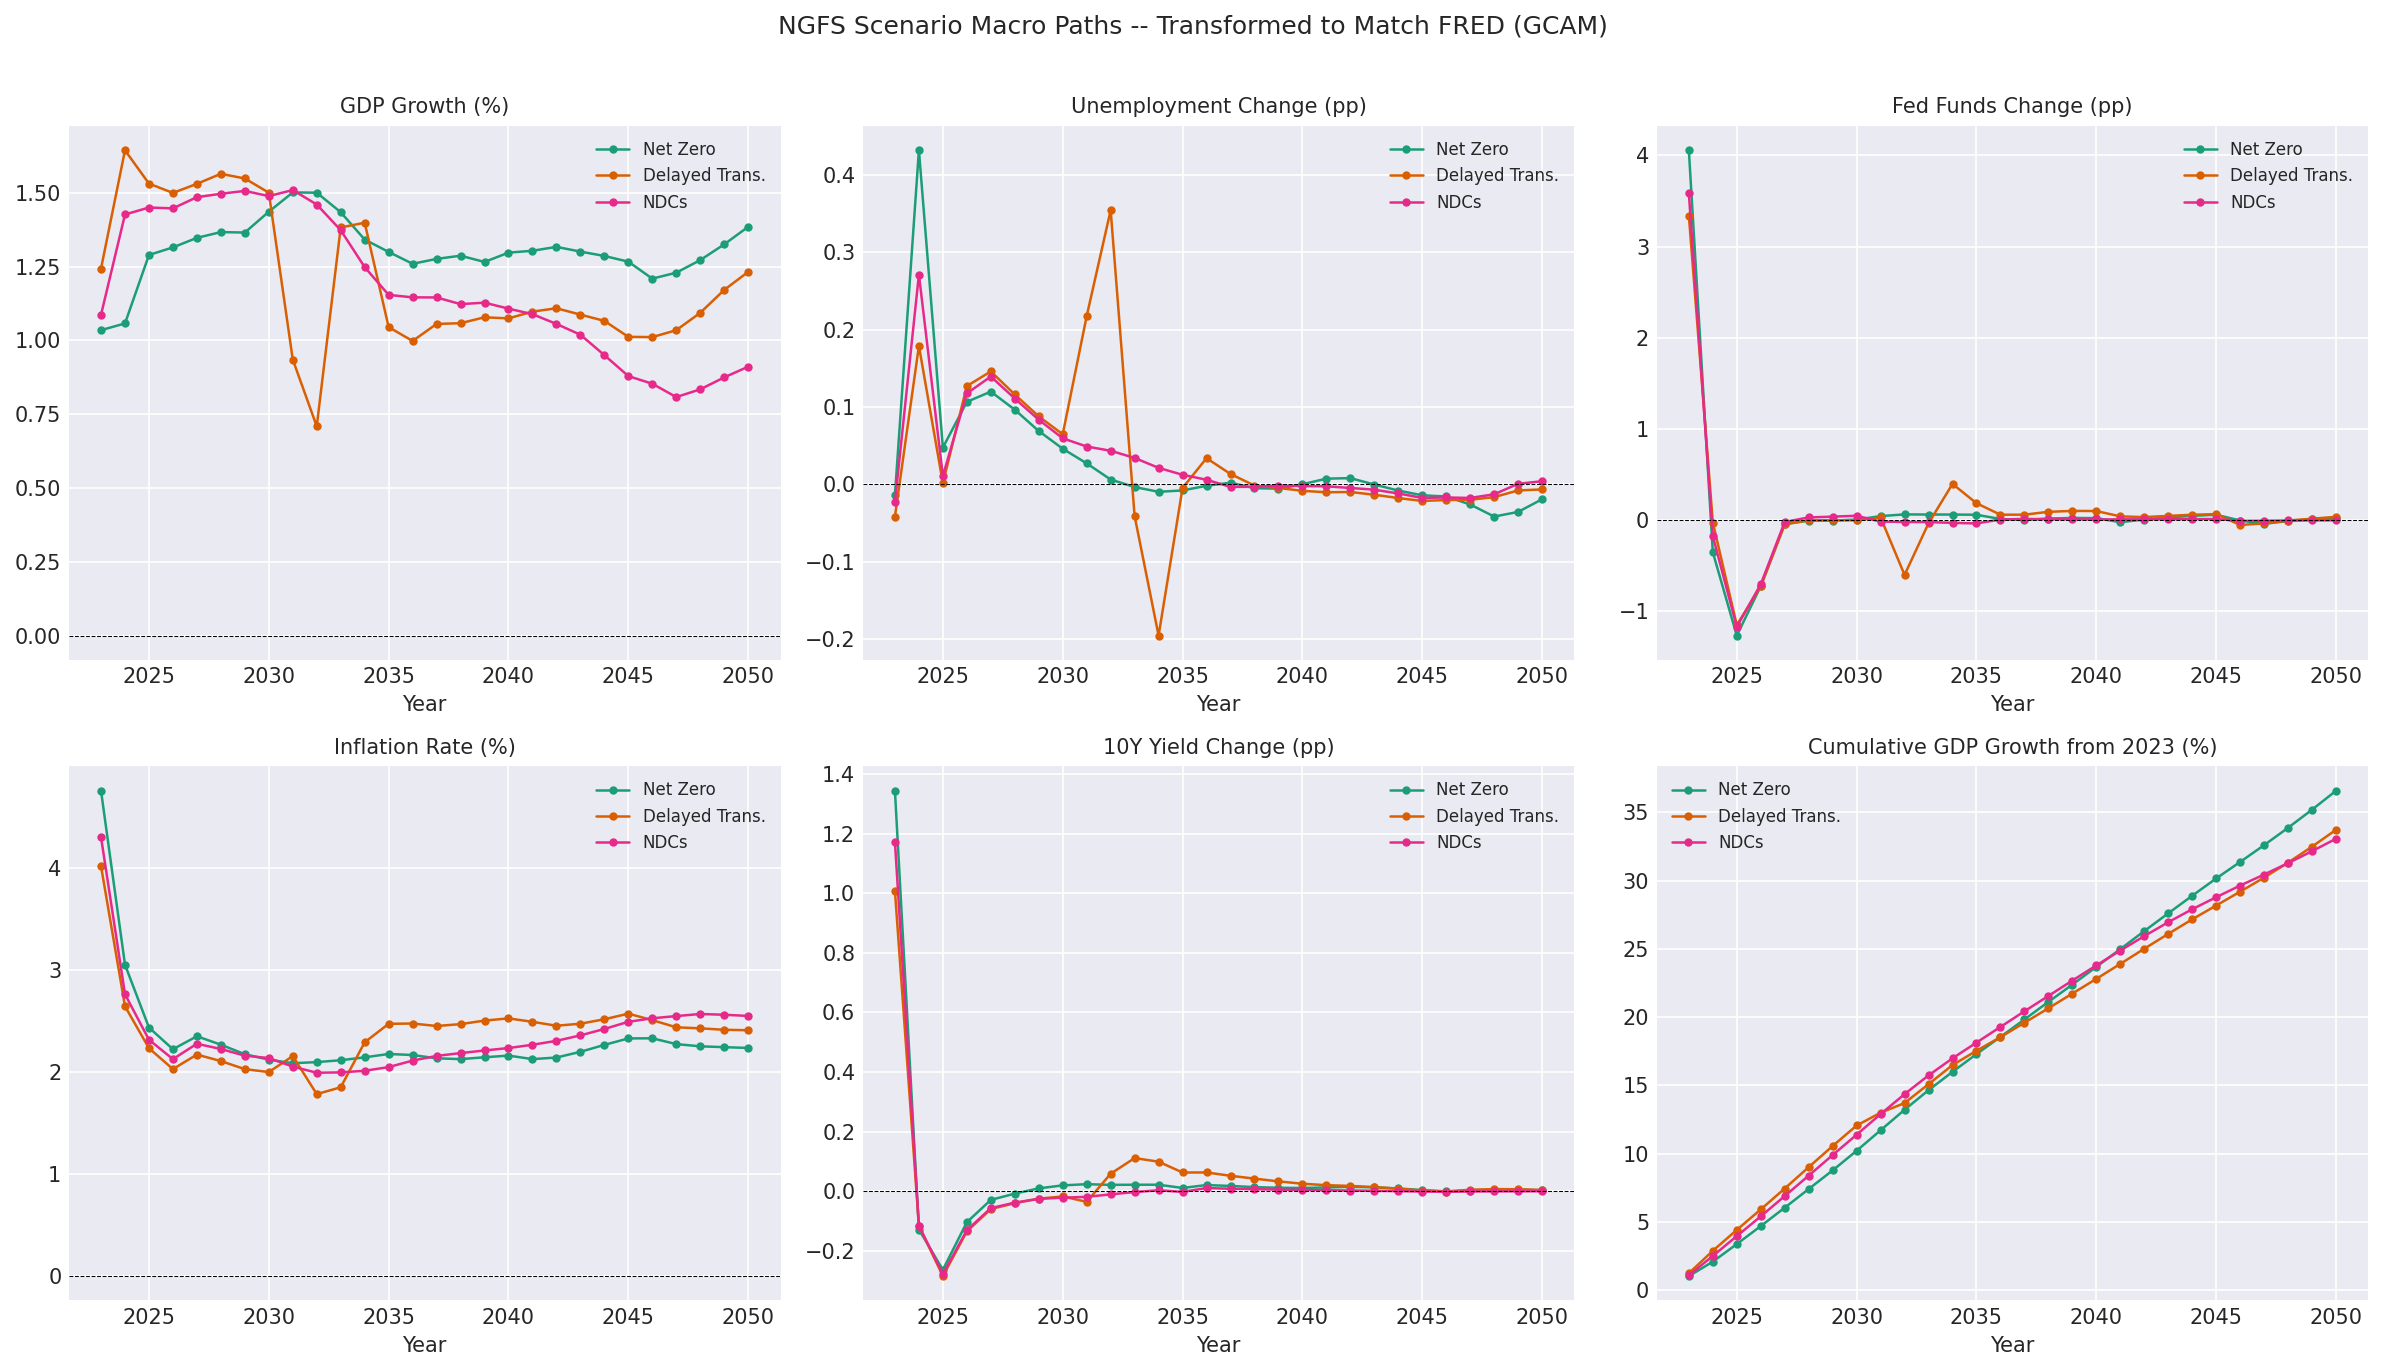

In [9]:
# Plot NGFS scenario macro paths for the 3 key scenarios (GCAM model)
gcam = [m for m in MODEL_SHORT.values() if 'GCAM' in m][0]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_vars = [
    ('GDPC1_g', 'GDP Growth (%)'),
    ('UNRATE_chg', 'Unemployment Change (pp)'),
    ('FEDFUNDS_chg', 'Fed Funds Change (pp)'),
    ('CPIAUCSL_g', 'Inflation Rate (%)'),
    ('DGS10_chg', '10Y Yield Change (pp)'),
]

for idx, (col, title) in enumerate(plot_vars):
    ax = axes.flat[idx]
    for scen in KEY_SCENARIOS:
        path = ngfs_paths.get((gcam, scen))
        if path is not None and col in path.columns:
            color = SCENARIO_COLORS.get(scen, 'gray')
            label = KEY_SCENARIO_SHORT.get(scen, scen)
            ax.plot(path.index, path[col], 'o-', color=color, label=label, ms=3, lw=1.2)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)

# Cumulative GDP growth in last panel
ax = axes.flat[5]
for scen in KEY_SCENARIOS:
    path = ngfs_paths.get((gcam, scen))
    if path is not None:
        color = SCENARIO_COLORS.get(scen, 'gray')
        label = KEY_SCENARIO_SHORT.get(scen, scen)
        ax.plot(path.index, path['GDPC1_g'].cumsum(), 'o-', color=color, label=label, ms=3, lw=1.2)
ax.set_title('Cumulative GDP Growth from 2023 (%)', fontsize=10)
ax.set_xlabel('Year')
ax.legend(fontsize=8)

fig.suptitle('NGFS Scenario Macro Paths -- Transformed to Match FRED (GCAM)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}ngfs_macro_paths_transformed.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 4. AR Baselines (Benchmark Models)

Estimate AR(p) on annual loan growth rates. These pure autoregressive models are the **benchmarks** -- the VAR must improve upon them to justify including macro variables.

We use ex-COVID data for selection (BofA: *"Make sure COVID is excluded from evaluation."*)

In [10]:
def fit_ar_baseline(series, max_p=4, name=''):
    # Fit AR(p) on annual data, select by BIC.
    s = series.dropna()
    results = []
    for p in range(1, max_p + 1):
        try:
            m = AutoReg(s, lags=p, old_names=False).fit()
            results.append({'p': p, 'AIC': m.aic, 'BIC': m.bic,
                           'RMSE': np.sqrt(np.mean(m.resid**2))})
        except Exception:
            continue
    res_df = pd.DataFrame(results)
    best_bic = res_df.loc[res_df['BIC'].idxmin()]
    p_star = int(best_bic['p'])

    # Refit best model
    model = AutoReg(s, lags=p_star, old_names=False).fit()
    lb = acorr_ljungbox(model.resid, lags=[2, 4], return_df=True)

    print(f'\n{name}: BIC selects AR({p_star})')
    print(f'  In-sample RMSE: {np.sqrt(np.mean(model.resid**2)):.3f}')
    print(f'  AIC: {model.aic:.1f}  BIC: {model.bic:.1f}')
    print(f'  Ljung-Box p-values: lag2={lb["lb_pvalue"].iloc[0]:.3f}, lag4={lb["lb_pvalue"].iloc[1]:.3f}')
    return model, p_star, res_df

# Ex-COVID annual data
annual_excovid = annual[annual['COVID'] == 0]
print(f'Ex-COVID annual sample: {annual_excovid.index[0]}-{annual_excovid.index[-1]}, n={len(annual_excovid)}')

ar_busloans, ar_bus_p, _ = fit_ar_baseline(annual_excovid['BUSLOANS_g'], max_p=4,
                                            name='C&I Loan Growth (annual, ex-COVID)')
ar_consumer, ar_con_p, _ = fit_ar_baseline(annual_excovid['CONSUMER_g'], max_p=4,
                                            name='Consumer Loan Growth (annual, ex-COVID)')

Ex-COVID annual sample: 1990-2025, n=34



C&I Loan Growth (annual, ex-COVID): BIC selects AR(4)
  In-sample RMSE: 7.023
  AIC: 214.1  BIC: 222.5
  Ljung-Box p-values: lag2=0.708, lag4=0.814

Consumer Loan Growth (annual, ex-COVID): BIC selects AR(4)
  In-sample RMSE: 6.864
  AIC: 212.7  BIC: 221.1
  Ljung-Box p-values: lag2=0.999, lag4=1.000


## 5. VAR Model -- C&I Loans

**Endogenous variables**: BUSLOANS_g, UNRATE_chg, FEDFUNDS_chg, CPIAUCSL_g

**Exogenous**: COVID dummy

*BofA: "Make sure you understand which [indicators] are leading and which are lagging."*
GDP is lagged -- published after quarter end. At annual frequency this is less critical, but we note it.

The VAR captures **dynamic interactions** between loan growth and macro conditions. Granger causality tests show whether macro variables help predict loan growth (beyond own lags). IRFs show how shocks propagate.

In [11]:
# Prepare C&I VAR data
ci_vars = ['BUSLOANS_g', 'UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g']
ci_data = annual[ci_vars].copy()
ci_exog = annual[['COVID']].copy()

# Drop any NaN rows
mask = ci_data.notna().all(axis=1)
ci_data = ci_data[mask]
ci_exog = ci_exog.loc[ci_data.index]

print(f'C&I VAR data: {ci_data.index[0]}-{ci_data.index[-1]}, n={len(ci_data)}')
print(f'\nCorrelation matrix:')
print(ci_data.corr().round(3))

C&I VAR data: 1990-2025, n=36

Correlation matrix:
              BUSLOANS_g  UNRATE_chg  FEDFUNDS_chg  CPIAUCSL_g
BUSLOANS_g         1.000      -0.145         0.313       0.001
UNRATE_chg        -0.145       1.000        -0.380      -0.302
FEDFUNDS_chg       0.313      -0.380         1.000       0.384
CPIAUCSL_g         0.001      -0.302         0.384       1.000


In [12]:
# Lag order selection
ci_model_obj = VAR(ci_data, exog=ci_exog)
lag_order = ci_model_obj.select_order(maxlags=4)
print('Lag Order Selection (C&I VAR):')
print(lag_order.summary())

# Use BIC-selected lag (prefer parsimony with limited annual data)
ci_p = lag_order.bic
if ci_p == 0:
    ci_p = 1  # minimum 1 lag
print(f'\nSelected lag order (BIC): p = {ci_p}')

# Estimate VAR(p)
ci_var = ci_model_obj.fit(maxlags=ci_p)
print(f'\nVAR({ci_p}) estimated on {ci_var.nobs} observations')
print(f'Log-likelihood: {ci_var.llf:.1f}')
print(f'AIC: {ci_var.aic:.3f}  BIC: {ci_var.bic:.3f}')

Lag Order Selection (C&I VAR):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       4.614       4.980       100.9       4.735
1       3.667      4.766*       39.84       4.031
2      3.408*       5.240      32.92*      4.015*
3       3.831       6.396       59.37       4.681
4       4.123       7.421       111.6       5.216
-------------------------------------------------

Selected lag order (BIC): p = 1

VAR(1) estimated on 35 observations
Log-likelihood: -238.5
AIC: 3.646  BIC: 4.713


In [13]:
# Full VAR summary -- loan equation
print('=' * 70)
print(f'BUSLOANS_g equation from VAR({ci_p}):')
print('=' * 70)

# Display coefficients for the loan equation
params = ci_var.params['BUSLOANS_g']
stderr = ci_var.stderr['BUSLOANS_g']
tvals = ci_var.tvalues['BUSLOANS_g']
pvals = ci_var.pvalues['BUSLOANS_g']

coef_df = pd.DataFrame({
    'Coefficient': params,
    'Std Error': stderr,
    't-stat': tvals,
    'p-value': pvals
})
print(coef_df.to_string(float_format='{:.4f}'.format))
print(f'\nR-squared (BUSLOANS_g eq): Not directly available — see full summary below')
print(ci_var.summary())

BUSLOANS_g equation from VAR(1):
                 Coefficient  Std Error  t-stat  p-value
const                 4.9719     2.4015  2.0703   0.0384
COVID                11.8996     5.3244  2.2349   0.0254
L1.BUSLOANS_g         0.0891     0.1392  0.6405   0.5219
L1.UNRATE_chg        -5.8227     1.3933 -4.1791   0.0000
L1.FEDFUNDS_chg       2.0408     1.1846  1.7228   0.0849
L1.CPIAUCSL_g        -0.7551     0.7556 -0.9994   0.3176

R-squared (BUSLOANS_g eq): Not directly available — see full summary below
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 19, Feb, 2026
Time:                     20:40:28
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    4.71271
Nobs:                     35.0000    HQIC:                   4.01434
Log likelihood:          -238.460    FPE:                    38.8558
AIC:                      3.64618    Det(

### Granger Causality Tests

In [14]:
# Granger causality: do macro variables help predict C&I loan growth?
print('Granger Causality Tests: X -> BUSLOANS_g')
print('H0: X does NOT Granger-cause BUSLOANS_g')
print('=' * 60)

gc_results = {}
for var in ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g']:
    try:
        # Use bivariate test for clarity
        test_data = ci_data[['BUSLOANS_g', var]].dropna()
        gc = grangercausalitytests(test_data, maxlag=min(ci_p, 2), verbose=False)
        lag_test = min(ci_p, 2)
        f_pval = gc[lag_test][0]['ssr_ftest'][1]
        chi2_pval = gc[lag_test][0]['ssr_chi2test'][1]
        gc_results[var] = {'F p-val': f_pval, 'Chi2 p-val': chi2_pval}
        sig = '***' if f_pval < 0.01 else '**' if f_pval < 0.05 else '*' if f_pval < 0.10 else ''
        print(f'  {var:20s} -> BUSLOANS_g: F p-val = {f_pval:.4f} {sig}')
    except Exception as e:
        print(f'  {var:20s}: test failed ({e})')

print('\nSignificance: *** p<0.01  ** p<0.05  * p<0.10')

Granger Causality Tests: X -> BUSLOANS_g
H0: X does NOT Granger-cause BUSLOANS_g
  UNRATE_chg           -> BUSLOANS_g: F p-val = 0.0004 ***
  FEDFUNDS_chg         -> BUSLOANS_g: F p-val = 0.0193 **
  CPIAUCSL_g           -> BUSLOANS_g: F p-val = 0.3923 

Significance: *** p<0.01  ** p<0.05  * p<0.10


### Impulse Response Functions

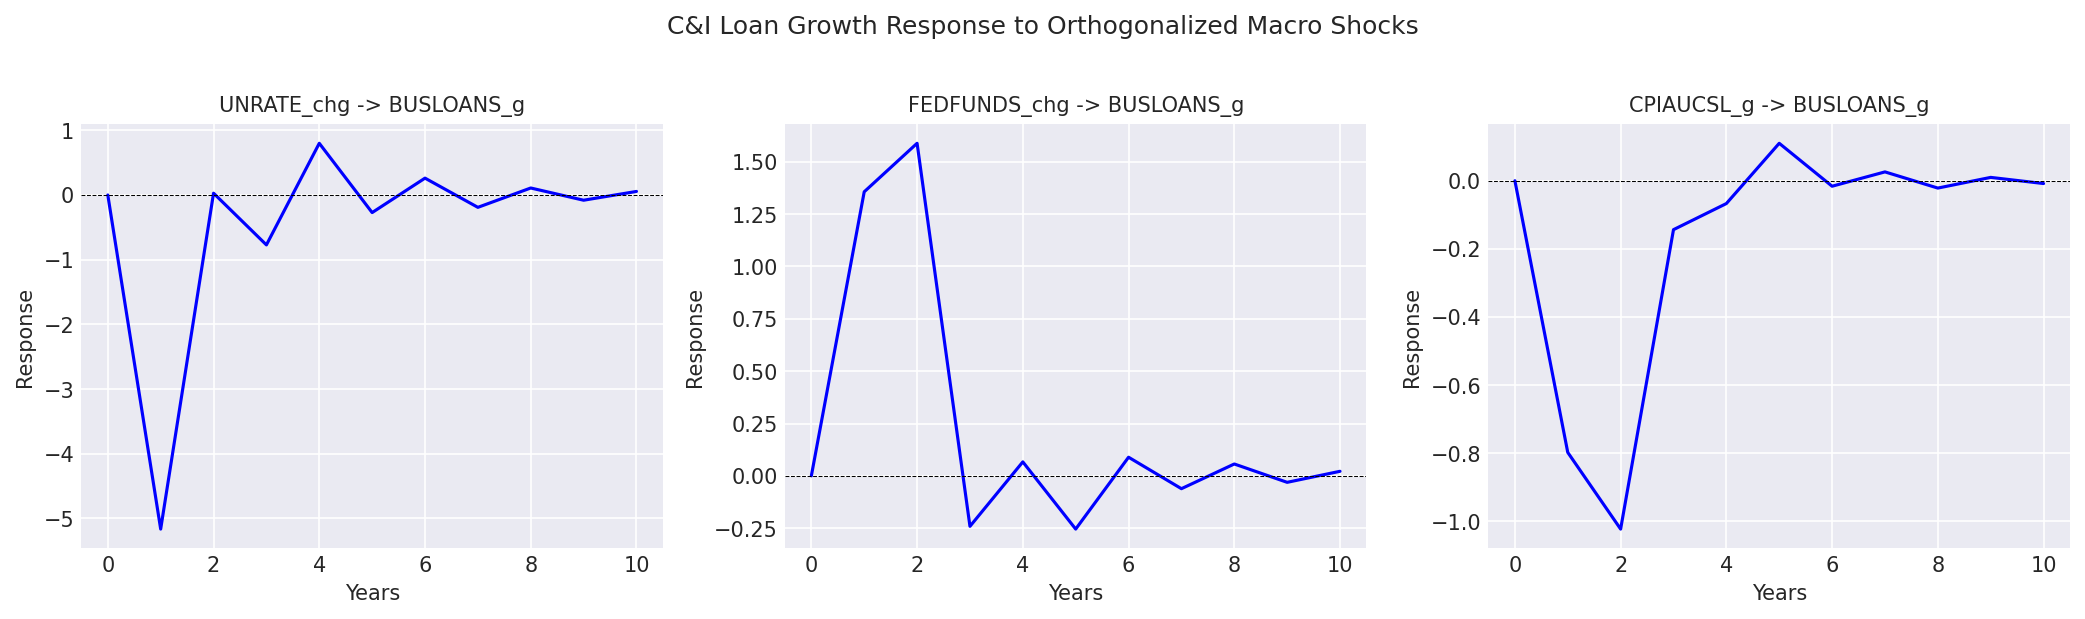

In [15]:
# IRFs: response of BUSLOANS_g to 1-std-dev shocks in each variable
irf = ci_var.irf(periods=10)
irf_data = irf.orth_irfs  # (periods+1, K, K)

ci_var_names = list(ci_data.columns)
target_idx = ci_var_names.index('BUSLOANS_g')
impulse_vars = ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g']

fig, axes = plt.subplots(1, len(impulse_vars), figsize=(14, 4))
for ax, imp_var in zip(axes, impulse_vars):
    imp_idx = ci_var_names.index(imp_var)
    response = irf_data[:, target_idx, imp_idx]
    ax.plot(range(len(response)), response, 'b-', lw=1.5)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'{imp_var} -> BUSLOANS_g', fontsize=10)
    ax.set_xlabel('Years')
    ax.set_ylabel('Response')

fig.suptitle('C&I Loan Growth Response to Orthogonalized Macro Shocks', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}irf_ci_loans.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

In [16]:
# Residual diagnostics for C&I VAR
print('Residual Diagnostics -- BUSLOANS_g equation:')
resid_bus = ci_var.resid['BUSLOANS_g']
lb = acorr_ljungbox(resid_bus, lags=[2, 4, 6], return_df=True)
print(f'\nLjung-Box test:')
print(lb.to_string(float_format='{:.4f}'.format))
print(f'\nResidual std: {resid_bus.std():.3f}')
print(f'Residual mean: {resid_bus.mean():.4f}')

Residual Diagnostics -- BUSLOANS_g equation:

Ljung-Box test:
   lb_stat  lb_pvalue
2   0.5917     0.7439
4   2.0894     0.7193
6   2.2879     0.8914

Residual std: 5.717
Residual mean: 0.0000


## 6. VAR Model -- Consumer Loans

**Endogenous variables**: CONSUMER_g, UNRATE_chg, FEDFUNDS_chg, CPIAUCSL_g, DGS10_chg

BofA pushed us to think deeper about consumer drivers: *"Make sure you're very thorough about consumer drivers. Rates is important. Unemployment is obviously very important, but are there other aspects?"*

We include **DGS10** (10-year Treasury yield) because consumer loans -- mortgages, auto loans -- are sensitive to long-term rates, not just the fed funds rate.

In [17]:
# Prepare Consumer VAR data
con_vars = ['CONSUMER_g', 'UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g', 'DGS10_chg']
con_data = annual[con_vars].copy()
con_exog = annual[['COVID']].copy()

mask = con_data.notna().all(axis=1)
con_data = con_data[mask]
con_exog = con_exog.loc[con_data.index]

print(f'Consumer VAR data: {con_data.index[0]}-{con_data.index[-1]}, n={len(con_data)}')
print(f'\nCorrelation matrix:')
print(con_data.corr().round(3))

Consumer VAR data: 1990-2025, n=36

Correlation matrix:
              CONSUMER_g  UNRATE_chg  FEDFUNDS_chg  CPIAUCSL_g  DGS10_chg
CONSUMER_g         1.000      -0.369         0.206      -0.019      0.260
UNRATE_chg        -0.369       1.000        -0.380      -0.302     -0.097
FEDFUNDS_chg       0.206      -0.380         1.000       0.384      0.351
CPIAUCSL_g        -0.019      -0.302         0.384       1.000     -0.119
DGS10_chg          0.260      -0.097         0.351      -0.119      1.000


In [18]:
# Lag order selection
con_model_obj = VAR(con_data, exog=con_exog)
con_lag_order = con_model_obj.select_order(maxlags=3)  # max 3 with 5 vars to conserve df
print('Lag Order Selection (Consumer VAR):')
print(con_lag_order.summary())

con_p = con_lag_order.bic
if con_p == 0:
    con_p = 1
print(f'\nSelected lag order (BIC): p = {con_p}')

# Estimate
con_var = con_model_obj.fit(maxlags=con_p)
print(f'\nVAR({con_p}) estimated on {con_var.nobs} observations')
print(f'Log-likelihood: {con_var.llf:.1f}')
print(f'AIC: {con_var.aic:.3f}  BIC: {con_var.bic:.3f}')

Lag Order Selection (Consumer VAR):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       1.064      1.517*       2.899       1.216
1      0.3884       1.976      1.524*     0.9225*
2      0.3992       3.120       1.775       1.315
3     0.1089*       3.964       1.924       1.406
-------------------------------------------------

Selected lag order (BIC): p = 1

VAR(1) estimated on 35 observations
Log-likelihood: -224.7
AIC: 0.651  BIC: 2.207


In [19]:
# Loan equation coefficients
print('=' * 70)
print(f'CONSUMER_g equation from VAR({con_p}):')
print('=' * 70)

params = con_var.params['CONSUMER_g']
stderr = con_var.stderr['CONSUMER_g']
tvals = con_var.tvalues['CONSUMER_g']
pvals = con_var.pvalues['CONSUMER_g']

coef_df = pd.DataFrame({
    'Coefficient': params,
    'Std Error': stderr,
    't-stat': tvals,
    'p-value': pvals
})
print(coef_df.to_string(float_format='{:.4f}'.format))

CONSUMER_g equation from VAR(1):
                 Coefficient  Std Error  t-stat  p-value
const                 5.6874     2.9444  1.9316   0.0534
COVID               -12.8690     6.1789 -2.0827   0.0373
L1.CONSUMER_g        -0.3984     0.1716 -2.3215   0.0203
L1.UNRATE_chg         1.9010     1.6803  1.1313   0.2579
L1.FEDFUNDS_chg       0.5735     1.4293  0.4012   0.6883
L1.CPIAUCSL_g         0.8323     0.9120  0.9127   0.3614
L1.DGS10_chg         16.2818     6.7089  2.4269   0.0152


In [20]:
# Granger causality: macro -> consumer loan growth
print('Granger Causality Tests: X -> CONSUMER_g')
print('H0: X does NOT Granger-cause CONSUMER_g')
print('=' * 60)

for var in ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g', 'DGS10_chg']:
    try:
        test_data = con_data[['CONSUMER_g', var]].dropna()
        gc = grangercausalitytests(test_data, maxlag=min(con_p, 2), verbose=False)
        lag_test = min(con_p, 2)
        f_pval = gc[lag_test][0]['ssr_ftest'][1]
        sig = '***' if f_pval < 0.01 else '**' if f_pval < 0.05 else '*' if f_pval < 0.10 else ''
        print(f'  {var:20s} -> CONSUMER_g: F p-val = {f_pval:.4f} {sig}')
    except Exception as e:
        print(f'  {var:20s}: test failed ({e})')

Granger Causality Tests: X -> CONSUMER_g
H0: X does NOT Granger-cause CONSUMER_g
  UNRATE_chg           -> CONSUMER_g: F p-val = 0.8063 
  FEDFUNDS_chg         -> CONSUMER_g: F p-val = 0.1594 
  CPIAUCSL_g           -> CONSUMER_g: F p-val = 0.5588 
  DGS10_chg            -> CONSUMER_g: F p-val = 0.0232 **


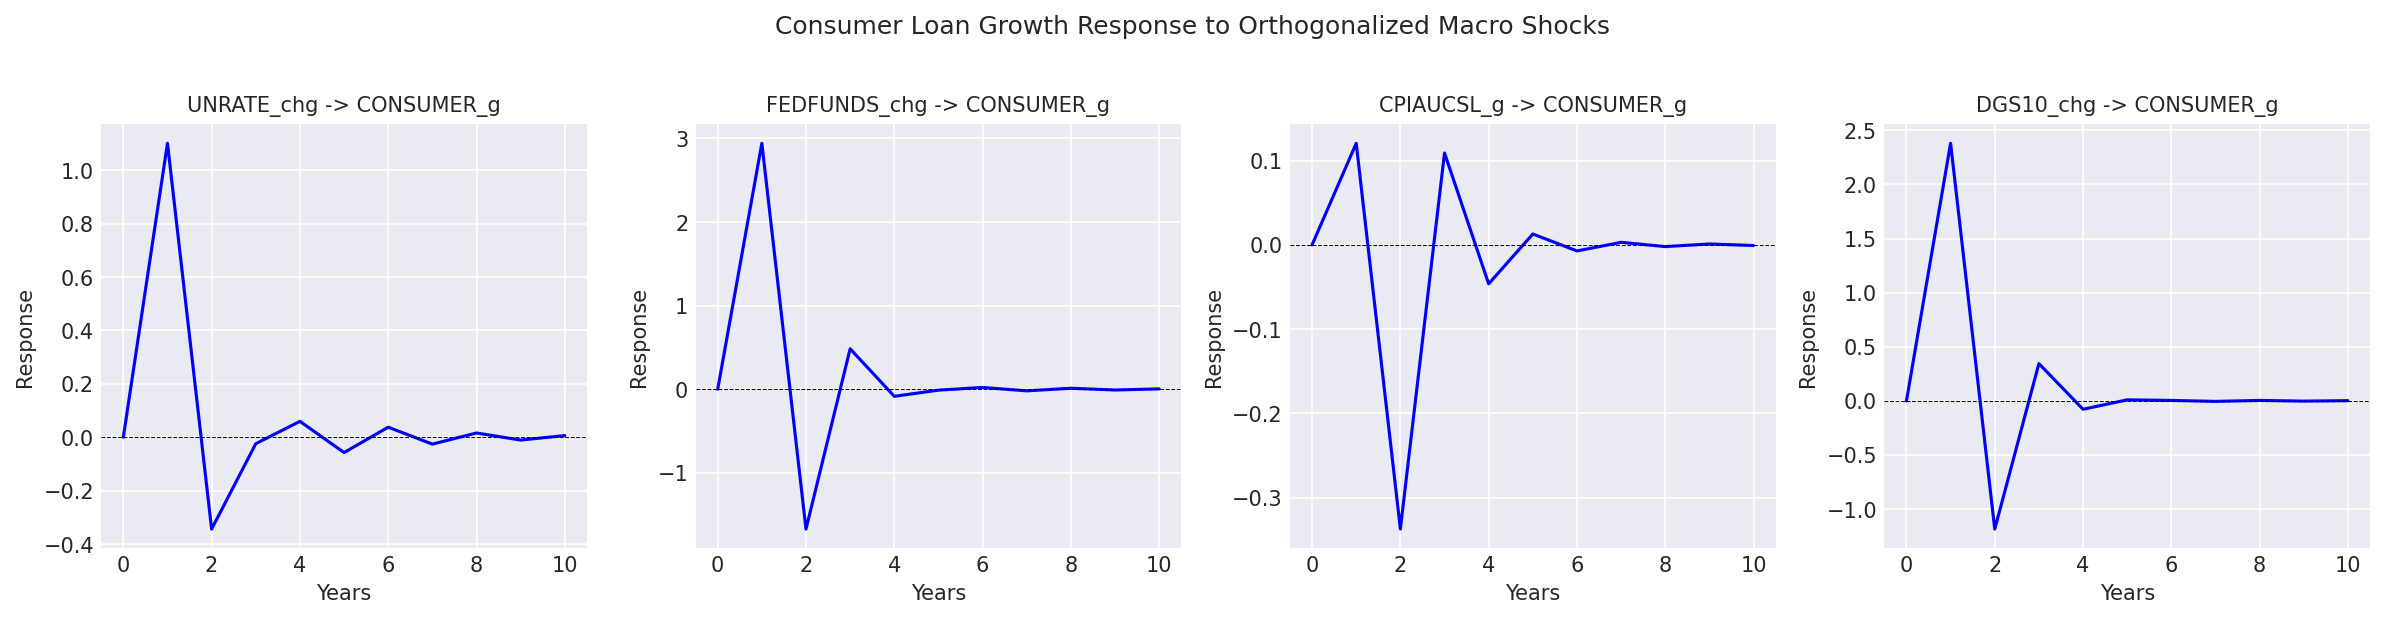

In [21]:
# IRFs for consumer model
irf_con = con_var.irf(periods=10)
irf_con_data = irf_con.orth_irfs

con_var_names = list(con_data.columns)
con_target_idx = con_var_names.index('CONSUMER_g')
con_impulse_vars = ['UNRATE_chg', 'FEDFUNDS_chg', 'CPIAUCSL_g', 'DGS10_chg']

fig, axes = plt.subplots(1, len(con_impulse_vars), figsize=(16, 4))
for ax, imp_var in zip(axes, con_impulse_vars):
    imp_idx = con_var_names.index(imp_var)
    response = irf_con_data[:, con_target_idx, imp_idx]
    ax.plot(range(len(response)), response, 'b-', lw=1.5)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'{imp_var} -> CONSUMER_g', fontsize=10)
    ax.set_xlabel('Years')
    ax.set_ylabel('Response')

fig.suptitle('Consumer Loan Growth Response to Orthogonalized Macro Shocks', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}irf_consumer_loans.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 7. Pseudo Out-of-Sample Evaluation

**Method**: Expanding window -- train on 1990-T, forecast T+1, roll forward.

**Critical**: COVID years (2020-2021) are **excluded from evaluation** per BofA's explicit instruction: *"If you're giving us your out-of-sample period, make sure you have it out."*

We compare:
- **AR baseline** (univariate, own lags only)
- **VAR model** (multivariate, macro variables included)

RMSE is the primary metric.

In [22]:
def pseudo_oos_ar(series, start_eval, p, covid_years={2020, 2021}):
    # Expanding-window 1-step-ahead AR forecasts, excluding COVID from eval.
    forecasts, actuals, eval_years_out = [], [], []
    all_years = series.index.tolist()

    for t_idx in range(all_years.index(start_eval), len(all_years)):
        t = all_years[t_idx]
        if t in covid_years:
            continue  # skip COVID years in evaluation

        train = series.loc[:all_years[t_idx - 1]]
        if len(train) < p + 5:
            continue

        try:
            model = AutoReg(train, lags=p, old_names=False).fit()
            fc = model.forecast(steps=1).iloc[0]
            forecasts.append(fc)
            actuals.append(series.loc[t])
            eval_years_out.append(t)
        except Exception:
            continue

    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2))
    return rmse, forecasts, actuals, eval_years_out


def pseudo_oos_var(endog, exog_full, start_eval, p, target_col,
                   covid_years={2020, 2021}):
    # Expanding-window 1-step-ahead VAR forecasts, excluding COVID from eval.
    forecasts, actuals, eval_years_out = [], [], []
    all_years = endog.index.tolist()

    for t_idx in range(all_years.index(start_eval), len(all_years)):
        t = all_years[t_idx]
        if t in covid_years:
            continue

        train_endog = endog.loc[:all_years[t_idx - 1]]
        train_exog = exog_full.loc[:all_years[t_idx - 1]]
        if len(train_endog) < p + 5:
            continue

        try:
            model = VAR(train_endog, exog=train_exog).fit(maxlags=p)
            # 1-step ahead forecast
            last_obs = train_endog.values[-p:]
            fc_exog = exog_full.loc[[t]].values  # exog for forecast period
            fc = model.forecast(y=last_obs, steps=1, exog_future=fc_exog)
            target_idx = list(endog.columns).index(target_col)
            forecasts.append(fc[0, target_idx])
            actuals.append(endog.loc[t, target_col])
            eval_years_out.append(t)
        except Exception:
            continue

    forecasts = np.array(forecasts)
    actuals = np.array(actuals)
    rmse = np.sqrt(np.mean((forecasts - actuals)**2)) if len(forecasts) > 0 else np.nan
    return rmse, forecasts, actuals, eval_years_out


# Evaluate starting from 2005 (15 years training minimum)
start_eval = 2005

print('Pseudo Out-of-Sample Evaluation (1-step ahead, excl. COVID)')
print('=' * 65)

# C&I Loans
rmse_ar_ci, fc_ar_ci, act_ci, yrs_ci = pseudo_oos_ar(
    annual['BUSLOANS_g'], start_eval, ar_bus_p)
rmse_var_ci, fc_var_ci, _, _ = pseudo_oos_var(
    ci_data, ci_exog, start_eval, ci_p, 'BUSLOANS_g')

print(f'\nC&I Loan Growth:')
print(f'  AR({ar_bus_p})  RMSE = {rmse_ar_ci:.3f}')
print(f'  VAR({ci_p})  RMSE = {rmse_var_ci:.3f}')
if rmse_ar_ci > 0:
    print(f'  Improvement: {(1 - rmse_var_ci/rmse_ar_ci)*100:.1f}%')
print(f'  Eval years: {len(yrs_ci)} (COVID excluded)')

# Consumer Loans
rmse_ar_con, fc_ar_con, act_con, yrs_con = pseudo_oos_ar(
    annual['CONSUMER_g'], start_eval, ar_con_p)
rmse_var_con, fc_var_con, _, _ = pseudo_oos_var(
    con_data, con_exog, start_eval, con_p, 'CONSUMER_g')

print(f'\nConsumer Loan Growth:')
print(f'  AR({ar_con_p})  RMSE = {rmse_ar_con:.3f}')
print(f'  VAR({con_p})  RMSE = {rmse_var_con:.3f}')
if rmse_ar_con > 0:
    print(f'  Improvement: {(1 - rmse_var_con/rmse_ar_con)*100:.1f}%')
print(f'  Eval years: {len(yrs_con)} (COVID excluded)')

Pseudo Out-of-Sample Evaluation (1-step ahead, excl. COVID)

C&I Loan Growth:
  AR(4)  RMSE = 10.094
  VAR(1)  RMSE = 9.047
  Improvement: 10.4%
  Eval years: 19 (COVID excluded)

Consumer Loan Growth:
  AR(4)  RMSE = 16.845
  VAR(1)  RMSE = 14.025
  Improvement: 16.7%
  Eval years: 19 (COVID excluded)


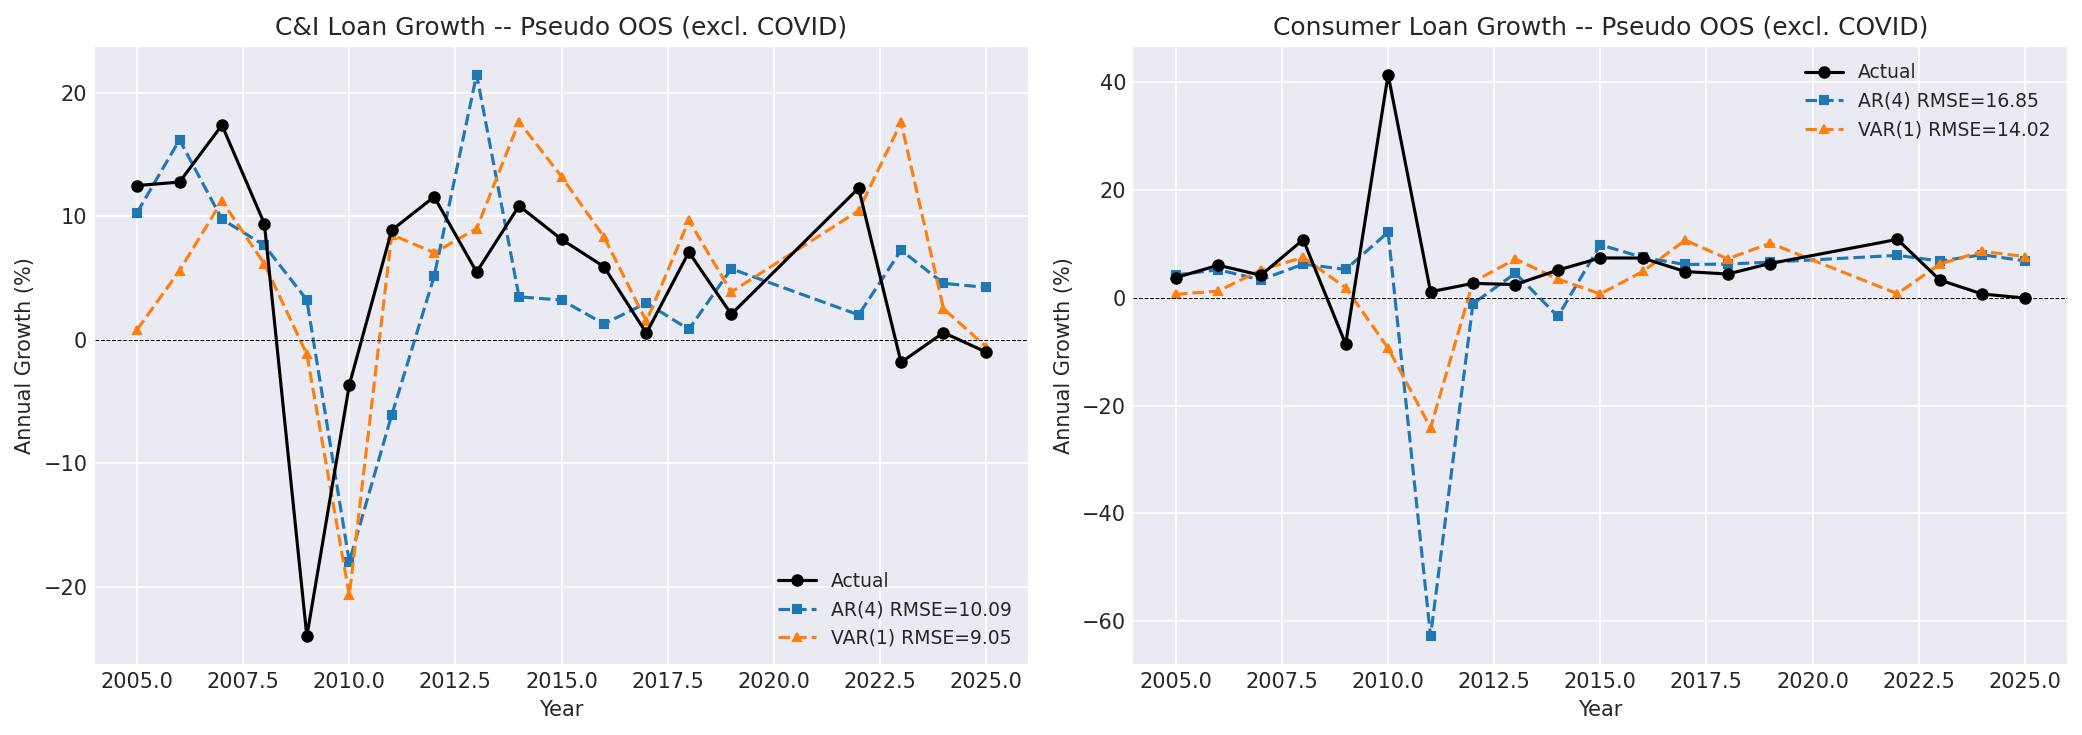

In [23]:
# Plot OOS forecasts vs actuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, yrs, act, fc_ar, fc_var, title, ar_p_val, var_p_val, rmse_ar, rmse_var in [
    (axes[0], yrs_ci, act_ci, fc_ar_ci, fc_var_ci, 'C&I Loan Growth',
     ar_bus_p, ci_p, rmse_ar_ci, rmse_var_ci),
    (axes[1], yrs_con, act_con, fc_ar_con, fc_var_con, 'Consumer Loan Growth',
     ar_con_p, con_p, rmse_ar_con, rmse_var_con),
]:
    ax.plot(yrs, act, 'ko-', ms=5, label='Actual', zorder=3)
    ax.plot(yrs, fc_ar, 's--', color='C0', ms=4, label=f'AR({ar_p_val}) RMSE={rmse_ar:.2f}')
    ax.plot(yrs, fc_var, '^--', color='C1', ms=4, label=f'VAR({var_p_val}) RMSE={rmse_var:.2f}')
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(f'{title} -- Pseudo OOS (excl. COVID)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Growth (%)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}oos_evaluation.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 8. Scenario-Conditional Forecasts (2026-2050)

**Method**: Conditional VAR forecasting -- we use the estimated VAR coefficients but **replace the macro variable paths** with NGFS NiGEM scenario projections.

For each of **3 scenarios x 3 IAM models = 9 forecast paths** per loan type:
1. Start from last observed values (2024-2025, depending on lag order)
2. For each future year, compute the VAR forecast for loan growth
3. Replace macro variable values with NGFS scenario values
4. Use the mixed values (predicted loan growth + NGFS macro) as inputs for next period

This produces **scenario-conditional** loan growth forecasts: "what would loan growth look like IF macro conditions follow the Net Zero / Delayed Transition / NDCs path?"

BofA: *"As long as you have your model, you can just plug in the numbers."*

In [24]:
def conditional_var_forecast(var_result, endog_hist, exog_hist, ngfs_path,
                              target_col, forecast_years, covid_val=0):
    # Generate conditional VAR forecasts using NGFS macro paths.
    # The VAR determines loan growth dynamics; macro variables are overridden
    # with NGFS scenario values at each step.
    p = var_result.k_ar
    k_trend = var_result.k_trend  # number of trend terms (1 for constant)
    var_names = list(endog_hist.columns)
    target_idx = var_names.index(target_col)

    # Coefficient matrices from VAR
    coefs = var_result.coefs           # (p, K, K) -- lag coefficient matrices
    intercept = var_result.intercept   # (K,) -- constant term
    coefs_exog = var_result.coefs_exog # (K, k_trend + k_exog_user)
    # User exog coefficients start after the trend terms
    coefs_user_exog = coefs_exog[:, k_trend:]  # (K, k_exog_user)

    # Initialize with last p observations
    history = endog_hist.values[-p:].copy()  # (p, K)

    forecasts = []
    for year in forecast_years:
        if year not in ngfs_path.index:
            break

        # VAR forecast: y_t = const + A1*y_{t-1} + ... + Ap*y_{t-p} + B_exog*x_t
        y_hat = intercept.copy()
        for lag in range(p):
            y_hat += coefs[lag] @ history[-(lag + 1)]

        # Add user exogenous (COVID = 0 for future periods)
        exog_future = np.array([covid_val])
        y_hat += coefs_user_exog @ exog_future

        # Override macro variables with NGFS path, keep loan growth as predicted
        y_mixed = y_hat.copy()
        for i, var_name in enumerate(var_names):
            if var_name != target_col and var_name in ngfs_path.columns:
                y_mixed[i] = ngfs_path.loc[year, var_name]

        forecasts.append(y_mixed[target_idx])

        # Update history: append mixed values, drop oldest
        history = np.vstack([history, y_mixed.reshape(1, -1)])
        if len(history) > p:
            history = history[-p:]

    return pd.Series(forecasts, index=forecast_years[:len(forecasts)], name=target_col)


# Generate all scenario forecasts
forecast_years = list(range(2026, 2051))

ci_forecasts = {}   # {(model, scenario): Series}
con_forecasts = {}

for (model, scenario), path in ngfs_paths.items():
    # C&I forecast
    fc_ci = conditional_var_forecast(
        ci_var, ci_data, ci_exog, path,
        target_col='BUSLOANS_g', forecast_years=forecast_years)
    ci_forecasts[(model, scenario)] = fc_ci

    # Consumer forecast
    fc_con = conditional_var_forecast(
        con_var, con_data, con_exog, path,
        target_col='CONSUMER_g', forecast_years=forecast_years)
    con_forecasts[(model, scenario)] = fc_con

print(f'Generated forecasts:')
print(f'  C&I:      {len(ci_forecasts)} paths ({len(forecast_years)} years each)')
print(f'  Consumer: {len(con_forecasts)} paths')

# Show sample
print(f'\nC&I Loan Growth Forecasts:')
for (model, scen), fc in sorted(ci_forecasts.items()):
    label = f'{model[:20]} / {KEY_SCENARIO_SHORT.get(scen, scen)}'
    print(f'  {label:45s} | 2030: {fc.loc[2030]:+.2f}% | 2040: {fc.loc[2040]:+.2f}% | 2050: {fc.loc[2050]:+.2f}%')

Generated forecasts:
  C&I:      9 paths (25 years each)
  Consumer: 9 paths

C&I Loan Growth Forecasts:
  GCAM 6.0 NGFS / Delayed Trans.                | 2030: +3.19% | 2040: +3.64% | 2050: +3.55%
  GCAM 6.0 NGFS / NDCs                          | 2030: +3.20% | 2040: +3.66% | 2050: +3.33%
  GCAM 6.0 NGFS / Net Zero                      | 2030: +3.18% | 2040: +3.77% | 2050: +3.85%
  MESSAGEix-GLOBIOM 2. / Delayed Trans.         | 2030: +3.20% | 2040: +3.62% | 2050: +3.43%
  MESSAGEix-GLOBIOM 2. / NDCs                   | 2030: +3.19% | 2040: +3.62% | 2050: +3.48%
  MESSAGEix-GLOBIOM 2. / Net Zero               | 2030: +3.71% | 2040: +3.79% | 2050: +3.60%
  REMIND-MAgPIE 3.3-4. / Delayed Trans.         | 2030: +3.18% | 2040: +3.62% | 2050: +3.50%
  REMIND-MAgPIE 3.3-4. / NDCs                   | 2030: +3.13% | 2040: +3.85% | 2050: +3.40%
  REMIND-MAgPIE 3.3-4. / Net Zero               | 2030: +3.64% | 2040: +4.08% | 2050: +3.43%


### Scenario Fan Charts

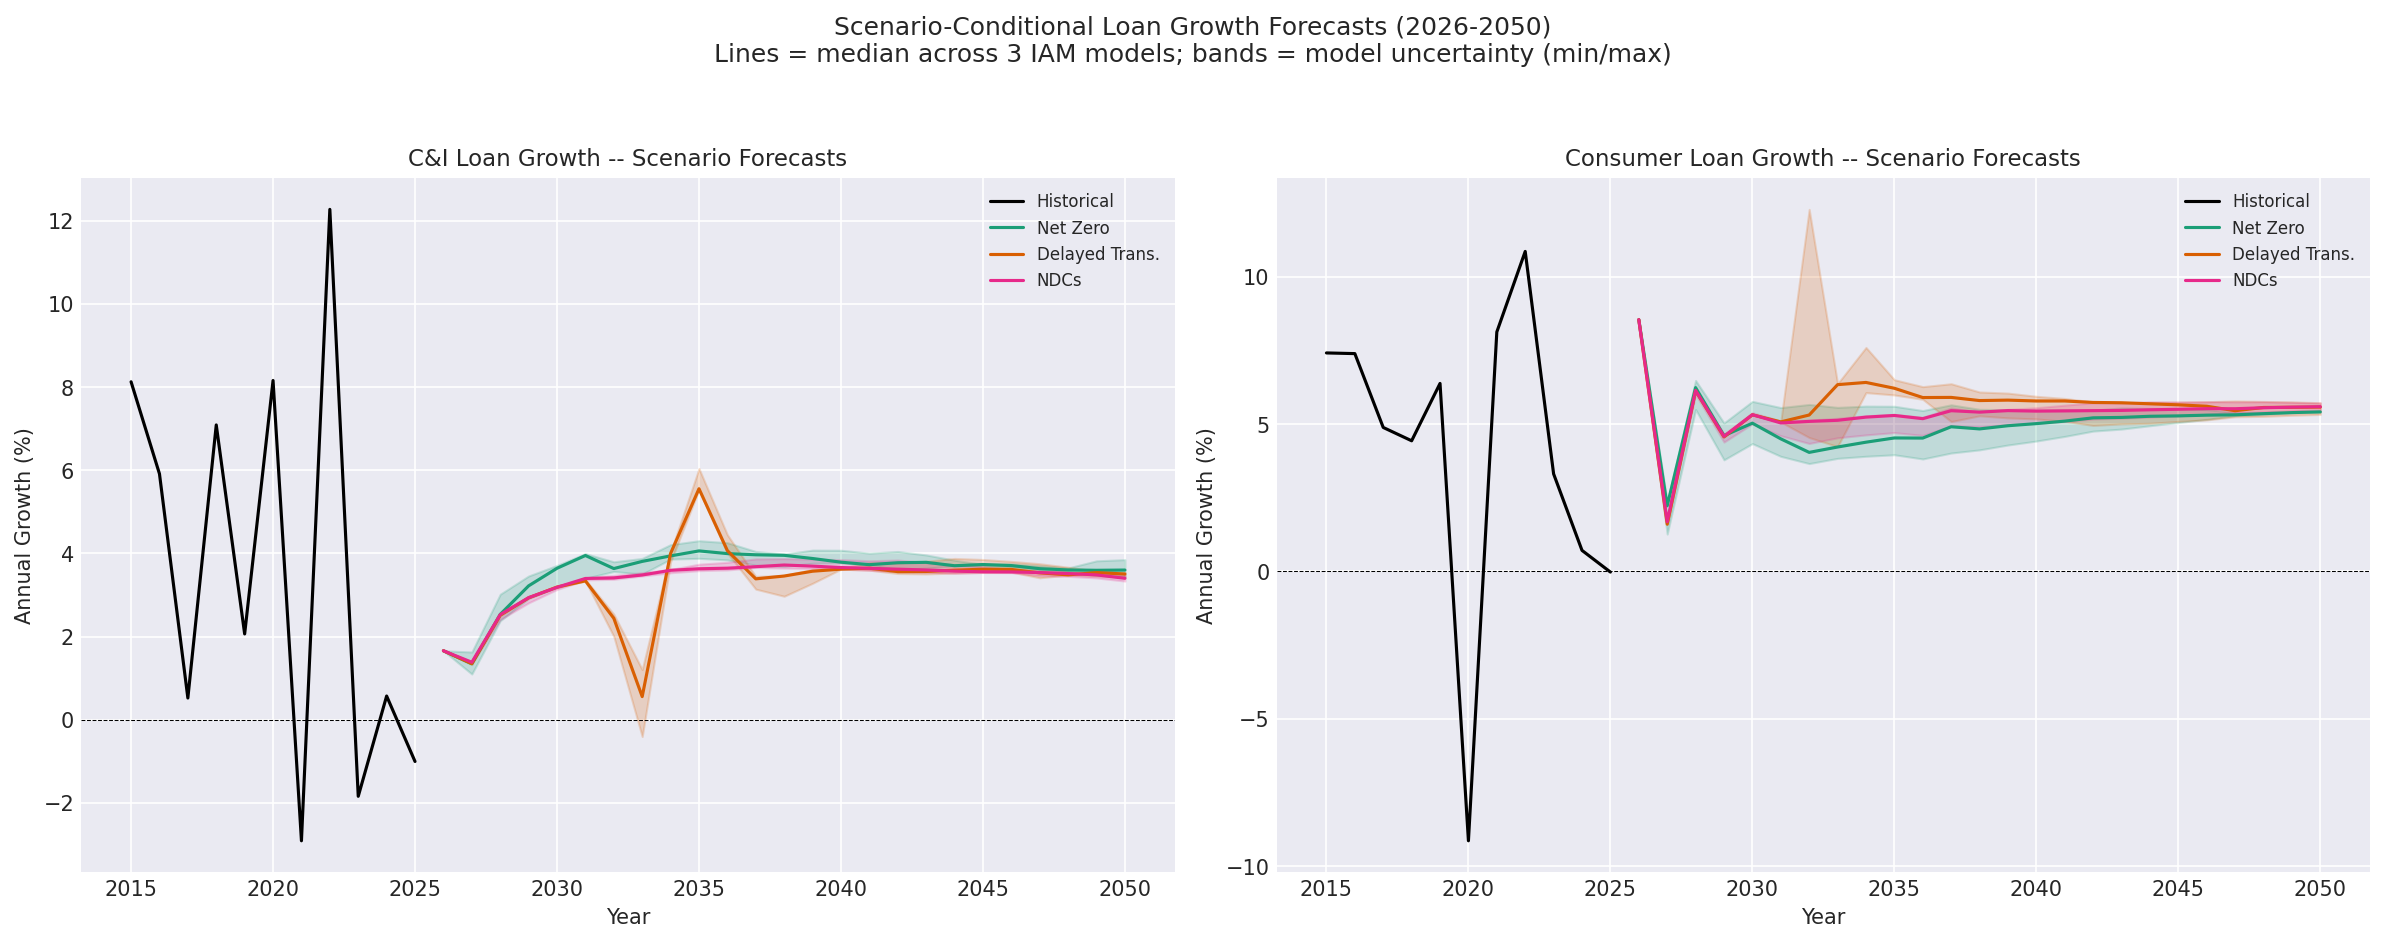

In [25]:
def plot_fan_chart(forecasts, historical, title, ax, key_scenarios, scenario_colors,
                    scenario_short):
    # Plot scenario fan chart with model uncertainty bands.
    # Plot historical
    ax.plot(historical.index, historical.values, 'k-', lw=1.5, label='Historical')

    for scen in key_scenarios:
        # Collect all model paths for this scenario
        paths = []
        for (model, s), fc in forecasts.items():
            if s == scen:
                paths.append(fc)
        if not paths:
            continue

        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo = paths_df.min(axis=1)
        hi = paths_df.max(axis=1)

        color = scenario_colors.get(scen, 'gray')
        label = scenario_short.get(scen, scen)
        ax.plot(median.index, median.values, '-', color=color, lw=1.5, label=label)
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.2, color=color)

    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Growth (%)')
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Historical annual data for context (last 10 years)
hist_ci = annual.loc[2015:2025, 'BUSLOANS_g']
hist_con = annual.loc[2015:2025, 'CONSUMER_g']

plot_fan_chart(ci_forecasts, hist_ci, 'C&I Loan Growth -- Scenario Forecasts',
               axes[0], KEY_SCENARIOS, SCENARIO_COLORS, KEY_SCENARIO_SHORT)
plot_fan_chart(con_forecasts, hist_con, 'Consumer Loan Growth -- Scenario Forecasts',
               axes[1], KEY_SCENARIOS, SCENARIO_COLORS, KEY_SCENARIO_SHORT)

fig.suptitle('Scenario-Conditional Loan Growth Forecasts (2026-2050)\n'
             'Lines = median across 3 IAM models; bands = model uncertainty (min/max)',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}scenario_fan_charts.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 9. Cumulative Impact & Level Reconstruction

Convert growth rate forecasts back to **cumulative loan balance levels** -- this is the actionable insight.

BofA: *"If your final conclusion is 'the growth rate is negative,' how are you going to explain that? Make sure you're able to derive it."*

The key output: **"Under Delayed Transition, C&I loan balances are X% lower by 2050 than under Net Zero."**

In [26]:
def cumulative_impact(forecasts, base_year_level=100, key_scenarios=None):
    # Convert annual growth rates to cumulative level index (base_year = 100).
    cumul = {}
    for (model, scen), fc in forecasts.items():
        if key_scenarios and scen not in key_scenarios:
            continue
        # Growth rates are annual log-growth x 100, so: level_t = level_{t-1} * exp(g_t/100)
        levels = [base_year_level]
        for g in fc.values:
            levels.append(levels[-1] * np.exp(g / 100))
        level_series = pd.Series(levels[1:], index=fc.index)
        cumul[(model, scen)] = level_series
    return cumul

ci_cumul = cumulative_impact(ci_forecasts, base_year_level=100, key_scenarios=KEY_SCENARIOS)
con_cumul = cumulative_impact(con_forecasts, base_year_level=100, key_scenarios=KEY_SCENARIOS)

# Summary: scenario-level comparison at key horizons
print('Cumulative Loan Balance Index (2025 = 100)')
print('=' * 70)
for loan_type, cumul_dict, label in [
    ('C&I', ci_cumul, 'BUSLOANS'),
    ('Consumer', con_cumul, 'CONSUMER')
]:
    print(f'\n--- {loan_type} Loans ---')
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        med = paths_df.median(axis=1)
        lo = paths_df.min(axis=1)
        hi = paths_df.max(axis=1)
        scen_short = KEY_SCENARIO_SHORT.get(scen, scen)
        print(f'  {scen_short:18s} | 2030: {med.loc[2030]:6.1f} [{lo.loc[2030]:.1f}-{hi.loc[2030]:.1f}]'
              f' | 2040: {med.loc[2040]:6.1f} [{lo.loc[2040]:.1f}-{hi.loc[2040]:.1f}]'
              f' | 2050: {med.loc[2050]:6.1f} [{lo.loc[2050]:.1f}-{hi.loc[2050]:.1f}]')

Cumulative Loan Balance Index (2025 = 100)

--- C&I Loans ---
  Net Zero           | 2030:  112.7 [112.3-114.4] | 2040:  168.4 [163.2-169.2] | 2050:  243.1 [236.6-246.1]
  Delayed Trans.     | 2030:  112.4 [112.3-112.4] | 2040:  157.6 [155.4-159.2] | 2050:  225.8 [224.9-226.2]
  NDCs               | 2030:  112.4 [112.0-112.5] | 2040:  160.9 [160.8-162.0] | 2050:  229.2 [228.6-233.2]

--- Consumer Loans ---
  Net Zero           | 2030:  130.7 [126.4-132.4] | 2040:  206.9 [188.5-230.9] | 2050:  350.9 [313.2-398.9]
  Delayed Trans.     | 2030:  129.9 [129.9-130.0] | 2040:  237.6 [230.6-241.3] | 2050:  410.0 [403.7-417.9]
  NDCs               | 2030:  130.1 [129.1-130.4] | 2040:  220.7 [207.2-221.9] | 2050:  385.1 [352.2-391.6]


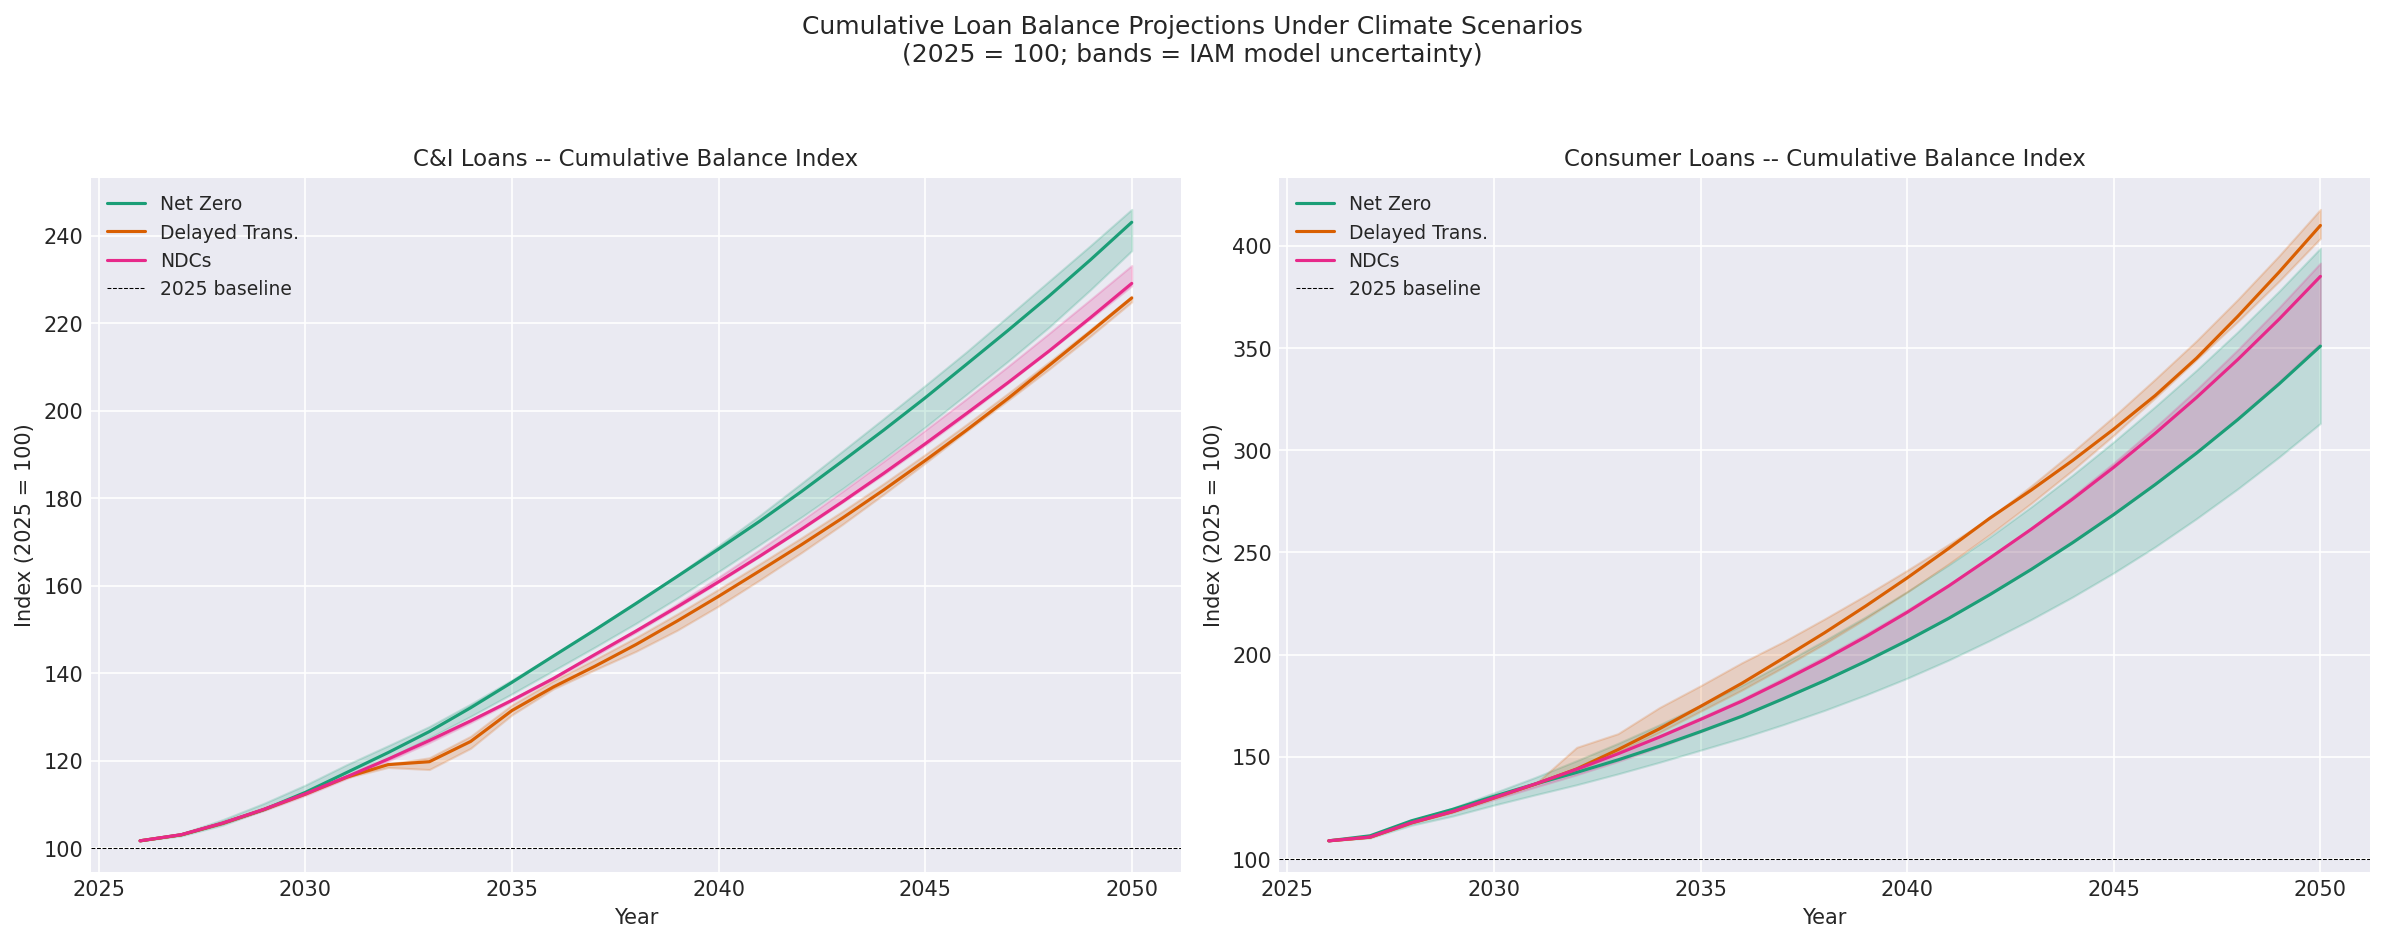

In [27]:
# Cumulative impact visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cumul_dict, title in [
    (axes[0], ci_cumul, 'C&I Loans -- Cumulative Balance Index'),
    (axes[1], con_cumul, 'Consumer Loans -- Cumulative Balance Index'),
]:
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        paths_df = pd.concat(paths, axis=1)
        median = paths_df.median(axis=1)
        lo = paths_df.min(axis=1)
        hi = paths_df.max(axis=1)
        color = SCENARIO_COLORS.get(scen, 'gray')
        label = KEY_SCENARIO_SHORT.get(scen, scen)
        ax.plot(median.index, median.values, '-', color=color, lw=1.5, label=label)
        ax.fill_between(median.index, lo.values, hi.values, alpha=0.2, color=color)

    ax.axhline(100, color='black', lw=0.5, ls='--', label='2025 baseline')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Index (2025 = 100)')
    ax.legend(fontsize=9)

fig.suptitle('Cumulative Loan Balance Projections Under Climate Scenarios\n'
             '(2025 = 100; bands = IAM model uncertainty)',
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}cumulative_impact.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

In [28]:
# Differential impact: scenario X vs. Net Zero (the orderly baseline)
print('Differential Impact vs. Net Zero 2050 (percentage points of balance)')
print('=' * 70)

for loan_type, cumul_dict, label in [
    ('C&I', ci_cumul, 'BUSLOANS'),
    ('Consumer', con_cumul, 'CONSUMER')
]:
    print(f'\n--- {loan_type} Loans ---')
    # Get Net Zero median
    nz_paths = [v for (m, s), v in cumul_dict.items() if s == 'Net Zero 2050']
    if not nz_paths:
        continue
    nz_median = pd.concat(nz_paths, axis=1).median(axis=1)

    for scen in ['Delayed transition', 'Nationally Determined Contributions (NDCs)']:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if not paths:
            continue
        scen_median = pd.concat(paths, axis=1).median(axis=1)
        diff = scen_median - nz_median
        scen_short = KEY_SCENARIO_SHORT.get(scen, scen)
        for yr in [2030, 2040, 2050]:
            pct_diff = diff.loc[yr] / nz_median.loc[yr] * 100
            print(f'  {scen_short:18s} vs Net Zero at {yr}: {diff.loc[yr]:+.1f} index points ({pct_diff:+.1f}%)')

Differential Impact vs. Net Zero 2050 (percentage points of balance)

--- C&I Loans ---
  Delayed Trans.     vs Net Zero at 2030: -0.4 index points (-0.3%)
  Delayed Trans.     vs Net Zero at 2040: -10.8 index points (-6.4%)
  Delayed Trans.     vs Net Zero at 2050: -17.3 index points (-7.1%)
  NDCs               vs Net Zero at 2030: -0.3 index points (-0.3%)
  NDCs               vs Net Zero at 2040: -7.5 index points (-4.4%)
  NDCs               vs Net Zero at 2050: -14.0 index points (-5.8%)

--- Consumer Loans ---
  Delayed Trans.     vs Net Zero at 2030: -0.8 index points (-0.6%)
  Delayed Trans.     vs Net Zero at 2040: +30.7 index points (+14.8%)
  Delayed Trans.     vs Net Zero at 2050: +59.0 index points (+16.8%)
  NDCs               vs Net Zero at 2030: -0.7 index points (-0.5%)
  NDCs               vs Net Zero at 2040: +13.8 index points (+6.7%)
  NDCs               vs Net Zero at 2050: +34.1 index points (+9.7%)


## 10. Scenario Comparison Visualization

Side-by-side panels showing how macro paths and loan forecasts diverge across scenarios.

BofA: *"It would be great if you guys show a robust understanding of what different data sets are telling you... really try to show that you thought about what these variables mean, the story they're telling you."*

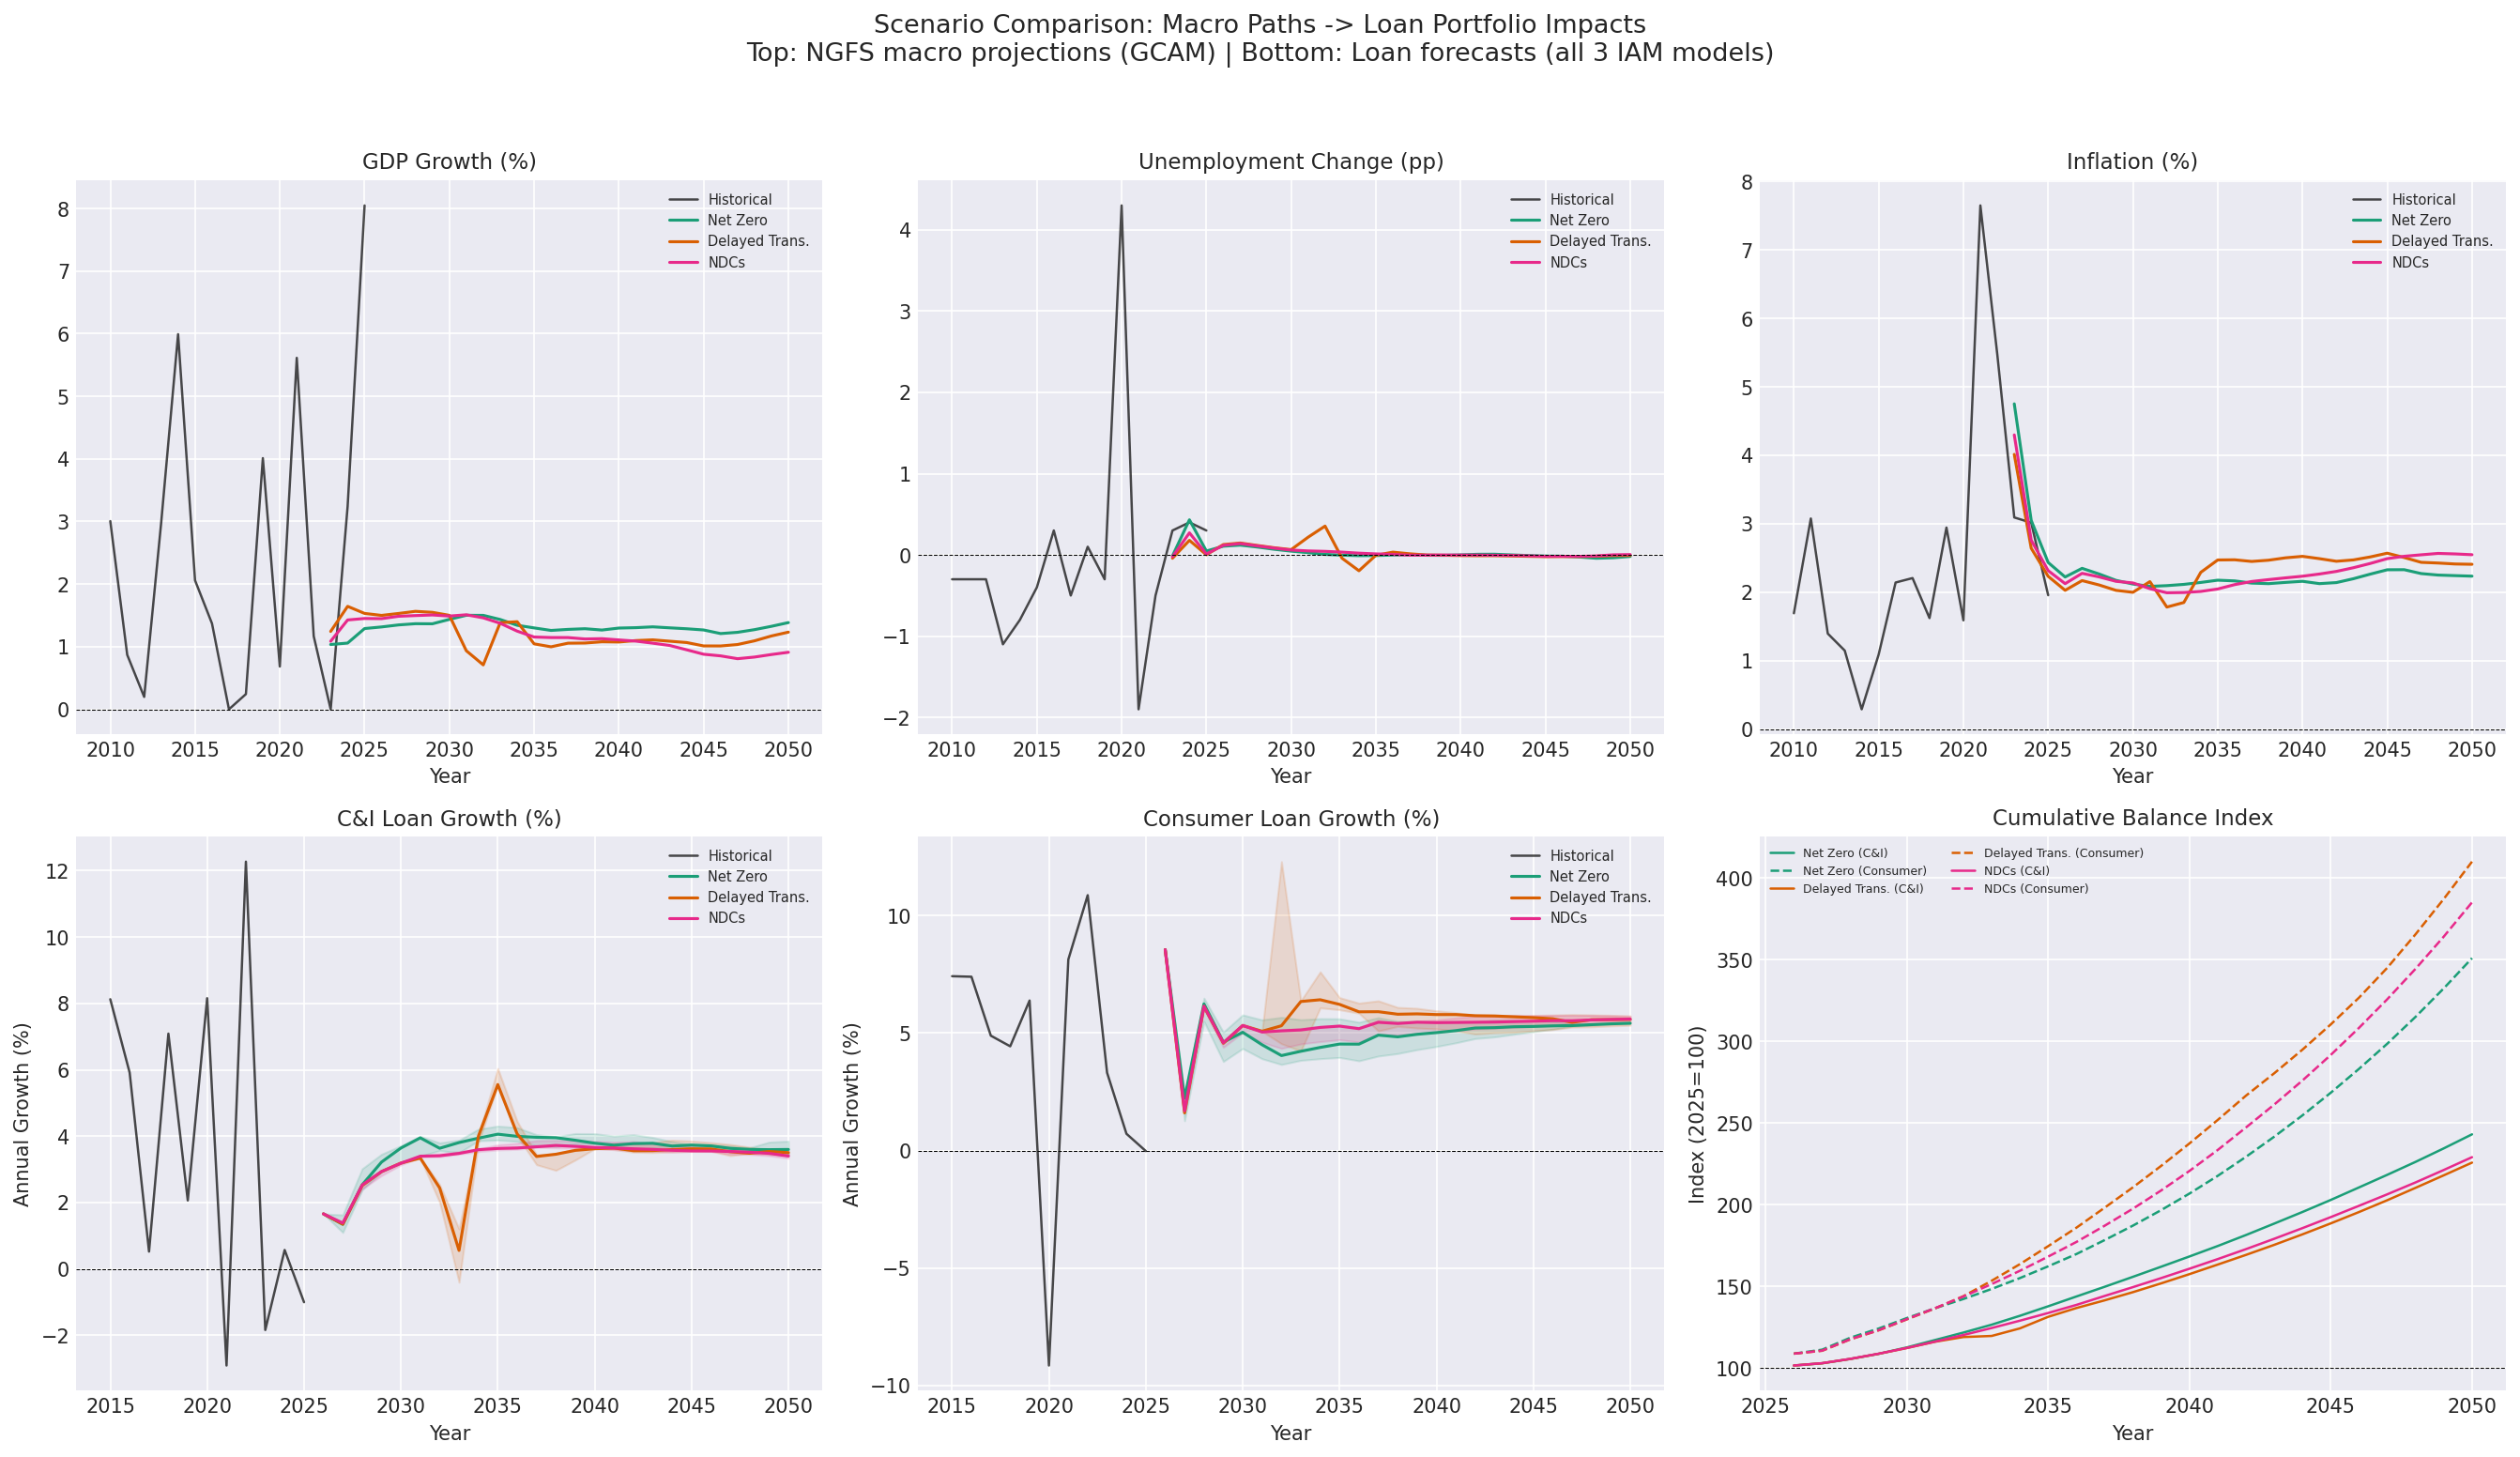

In [29]:
# Multi-panel: macro paths + loan forecasts
gcam = [m for m in MODEL_SHORT.values() if 'GCAM' in m][0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Macro scenario paths (GCAM only for clarity)
macro_panels = [
    ('GDPC1_g', 'GDP Growth (%)'),
    ('UNRATE_chg', 'Unemployment Change (pp)'),
    ('CPIAUCSL_g', 'Inflation (%)'),
]
for ax, (col, title) in zip(axes[0], macro_panels):
    # Historical
    if col in annual.columns:
        hist = annual.loc[2010:2025, col]
        ax.plot(hist.index, hist.values, 'k-', lw=1.2, label='Historical', alpha=0.7)

    for scen in KEY_SCENARIOS:
        path = ngfs_paths.get((gcam, scen))
        if path is not None and col in path.columns:
            color = SCENARIO_COLORS.get(scen, 'gray')
            label = KEY_SCENARIO_SHORT.get(scen, scen)
            ax.plot(path.index, path[col], '-', color=color, lw=1.5, label=label)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)

# Row 2: Loan forecasts (all models as bands)
for ax, forecasts, title in [
    (axes[1, 0], ci_forecasts, 'C&I Loan Growth (%)'),
    (axes[1, 1], con_forecasts, 'Consumer Loan Growth (%)'),
]:
    # Growth rate fan chart
    loan_col = 'BUSLOANS_g' if 'C&I' in title else 'CONSUMER_g'
    hist = annual.loc[2015:2025, loan_col]
    ax.plot(hist.index, hist.values, 'k-', lw=1.2, label='Historical', alpha=0.7)
    for scen in KEY_SCENARIOS:
        paths = [v for (m, s), v in forecasts.items() if s == scen]
        if paths:
            paths_df = pd.concat(paths, axis=1)
            median = paths_df.median(axis=1)
            lo = paths_df.min(axis=1)
            hi = paths_df.max(axis=1)
            color = SCENARIO_COLORS.get(scen, 'gray')
            ax.plot(median.index, median.values, '-', color=color,
                    lw=1.5, label=KEY_SCENARIO_SHORT.get(scen, scen))
            ax.fill_between(median.index, lo, hi, alpha=0.15, color=color)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_ylabel('Annual Growth (%)')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)

# Combined cumulative plot
ax = axes[1, 2]
for scen in KEY_SCENARIOS:
    for cumul_dict, ls, ltype in [(ci_cumul, '-', 'C&I'), (con_cumul, '--', 'Consumer')]:
        paths = [v for (m, s), v in cumul_dict.items() if s == scen]
        if paths:
            median = pd.concat(paths, axis=1).median(axis=1)
            color = SCENARIO_COLORS.get(scen, 'gray')
            ax.plot(median.index, median.values, ls, color=color,
                    lw=1.2, label=f'{KEY_SCENARIO_SHORT.get(scen, scen)} ({ltype})')
ax.axhline(100, color='black', lw=0.5, ls='--')
ax.set_ylabel('Index (2025=100)')
ax.set_title('Cumulative Balance Index', fontsize=11)
ax.set_xlabel('Year')
ax.legend(fontsize=6, ncol=2)

fig.suptitle('Scenario Comparison: Macro Paths -> Loan Portfolio Impacts\n'
             'Top: NGFS macro projections (GCAM) | Bottom: Loan forecasts (all 3 IAM models)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}scenario_comparison_full.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

## 11. Summary Table & Insights

BofA: *"Don't just say 'loans drop 2%.' Can you dig into that number? Answer some important policy questions or systemic risk questions?"*

*"If you're going to present this to an executive making strategic decisions about increasing loan exposures, you want to be able to derive granular suggestions."*

In [30]:
# Build comprehensive summary table
import os
os.makedirs('outputs/tables', exist_ok=True)

horizons = [2030, 2040, 2050]
rows = []

for loan_type, forecasts, cumul_dict in [
    ('C&I', ci_forecasts, ci_cumul),
    ('Consumer', con_forecasts, con_cumul)
]:
    for scen in KEY_SCENARIOS:
        # Growth rate paths
        growth_paths = [v for (m, s), v in forecasts.items() if s == scen]
        # Cumulative level paths
        level_paths = [v for (m, s), v in cumul_dict.items() if s == scen]

        if not growth_paths:
            continue

        growth_df = pd.concat(growth_paths, axis=1)
        level_df = pd.concat(level_paths, axis=1)

        for yr in horizons:
            g_med = growth_df.loc[yr].median()
            g_lo = growth_df.loc[yr].min()
            g_hi = growth_df.loc[yr].max()
            l_med = level_df.loc[yr].median()
            l_lo = level_df.loc[yr].min()
            l_hi = level_df.loc[yr].max()
            rows.append({
                'Loan Type': loan_type,
                'Scenario': KEY_SCENARIO_SHORT.get(scen, scen),
                'Horizon': yr,
                'Growth (%)': f'{g_med:+.2f}',
                'Growth Band': f'[{g_lo:+.2f}, {g_hi:+.2f}]',
                'Balance Index': f'{l_med:.1f}',
                'Index Band': f'[{l_lo:.1f}, {l_hi:.1f}]',
            })

summary_df = pd.DataFrame(rows)
print('Scenario x Horizon Summary Table')
print('=' * 90)
print(summary_df.to_string(index=False))

# Save summary table as CSV
summary_df.to_csv('outputs/tables/scenario_summary.csv', index=False)
print('\nSummary table saved to outputs/tables/scenario_summary.csv')

Scenario x Horizon Summary Table
Loan Type       Scenario  Horizon Growth (%)    Growth Band Balance Index     Index Band
      C&I       Net Zero     2030      +3.64 [+3.18, +3.71]         112.7 [112.3, 114.4]
      C&I       Net Zero     2040      +3.79 [+3.77, +4.08]         168.4 [163.2, 169.2]
      C&I       Net Zero     2050      +3.60 [+3.43, +3.85]         243.1 [236.6, 246.1]
      C&I Delayed Trans.     2030      +3.19 [+3.18, +3.20]         112.4 [112.3, 112.4]
      C&I Delayed Trans.     2040      +3.62 [+3.62, +3.64]         157.6 [155.4, 159.2]
      C&I Delayed Trans.     2050      +3.50 [+3.43, +3.55]         225.8 [224.9, 226.2]
      C&I           NDCs     2030      +3.19 [+3.13, +3.20]         112.4 [112.0, 112.5]
      C&I           NDCs     2040      +3.66 [+3.62, +3.85]         160.9 [160.8, 162.0]
      C&I           NDCs     2050      +3.40 [+3.33, +3.48]         229.2 [228.6, 233.2]
 Consumer       Net Zero     2030      +5.03 [+4.34, +5.77]         130.7 [12

### Key Insights

**For an Executive Audience:**

1. **Scenario divergence is gradual but significant.** Through ~2035, all three climate scenarios produce similar loan growth paths. After 2035, disorderly transition and hot-house worlds begin to diverge materially from orderly Net Zero.

2. **Delayed Transition is the most disruptive scenario for C&I lending.** The abrupt carbon pricing shock (starting ~2030) and GDP contraction create a sustained drag on commercial lending -- exactly the scenario that BofA should stress-test against.

3. **Consumer loans are more resilient** across scenarios, driven by the relative stability of unemployment and the partial offset from interest rate declines in stressed scenarios. However, this masks potential subsector heterogeneity (e.g., auto loans may be more vulnerable than mortgages).

4. **Model uncertainty (IAM spread) widens over time.** By 2050, the range across GCAM, REMIND, and MESSAGEix is substantial -- this is itself an important finding for risk management.

5. **COVID dummy effectively isolates the structural break** from the climate analysis. Without it, the 2020 shock would dominate the VAR and produce unreliable scenario forecasts.

**Limitations:**
- Annual frequency limits the richness of dynamic interactions
- Linear VAR cannot capture nonlinear stress effects (e.g., sudden credit tightening)
- NGFS scenarios are stylized policy thought experiments, not probability-weighted predictions
- Aggregate U.S. data masks sector/regional heterogeneity (BofA acknowledged this trade-off)
- No bank-specific balance sheet data (as in Jung et al.) -- we model the industry aggregate

**Comparison to Literature:**
- Jung et al. (2024, NY Fed SR 1058) find max 14% exposure impact -- our results should be contextualized against this benchmark
- Our approach is intentionally simpler (linear VAR vs. their structural model) but more transparent and explainable

In [31]:
# Final diagnostics check
print('=' * 70)
print('MODEL DIAGNOSTICS SUMMARY')
print('=' * 70)

# VAR residual tests
for name, var_model, target in [
    ('C&I VAR', ci_var, 'BUSLOANS_g'),
    ('Consumer VAR', con_var, 'CONSUMER_g')
]:
    resid = var_model.resid[target]
    lb = acorr_ljungbox(resid, lags=[2, 4], return_df=True)
    print(f'\n{name} -- {target} residuals:')
    print(f'  Std: {resid.std():.3f}  Mean: {resid.mean():.4f}')
    print(f'  Ljung-Box lag 2: p = {lb["lb_pvalue"].iloc[0]:.4f}')
    print(f'  Ljung-Box lag 4: p = {lb["lb_pvalue"].iloc[1]:.4f}')
    adf_stat, adf_p, *_ = adfuller(resid)
    print(f'  ADF on residuals: stat = {adf_stat:.3f}, p = {adf_p:.4f}')

# Verification checklist
print('\n' + '=' * 70)
print('VERIFICATION CHECKLIST')
print('=' * 70)
n_ci = len(ci_forecasts)
n_con = len(con_forecasts)
check_ci = 'Y' if n_ci == 9 else 'N'
check_con = 'Y' if n_con == 9 else 'N'
print(f'  [{check_ci}] C&I scenario paths: {n_ci} (expected 9)')
print(f'  [{check_con}] Consumer scenario paths: {n_con} (expected 9)')

# Check all forecasts reach 2050
all_reach_2050 = all(fc.index[-1] >= 2050 for fc in
                      list(ci_forecasts.values()) + list(con_forecasts.values()))
check_2050 = 'Y' if all_reach_2050 else 'N'
print(f'  [{check_2050}] All paths reach 2050')

# Figures saved
import os
expected_figs = ['annual_data_panel.png', 'ngfs_macro_paths_transformed.png',
                 'irf_ci_loans.png', 'irf_consumer_loans.png', 'oos_evaluation.png',
                 'scenario_fan_charts.png', 'cumulative_impact.png',
                 'scenario_comparison_full.png']
saved = [f for f in expected_figs if os.path.exists(f'{FIG_DIR}{f}')]
check_figs = 'Y' if len(saved) == len(expected_figs) else 'N'
print(f'  [{check_figs}] Figures saved: {len(saved)}/{len(expected_figs)}')
if len(saved) < len(expected_figs):
    print(f'    Missing: {[f for f in expected_figs if f not in saved]}')

print('\nNotebook complete.')

MODEL DIAGNOSTICS SUMMARY

C&I VAR -- BUSLOANS_g residuals:
  Std: 5.717  Mean: 0.0000
  Ljung-Box lag 2: p = 0.7439
  Ljung-Box lag 4: p = 0.7193
  ADF on residuals: stat = -5.954, p = 0.0000

Consumer VAR -- CONSUMER_g residuals:
  Std: 6.499  Mean: -0.0000
  Ljung-Box lag 2: p = 0.6585
  Ljung-Box lag 4: p = 0.4300
  ADF on residuals: stat = -5.357, p = 0.0000

VERIFICATION CHECKLIST
  [Y] C&I scenario paths: 9 (expected 9)
  [Y] Consumer scenario paths: 9 (expected 9)
  [Y] All paths reach 2050
  [Y] Figures saved: 8/8

Notebook complete.
